In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 
sys.path.append('/home/cosweeney/code/Fits/')

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *
from JoCond.jocond.hgcf import *
from JoCond.jocond.myconfig import*

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})


0.6777 74.71913613009617 74.71913613009617


In [2]:
# Mass bin centers
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins
r_edges = np.linspace(5, 15, (15-5)+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0

massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


In [3]:
# bin 'bin mass' model samples
samp_path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_models/gal_model_bin_mass_samples_r_4_15.hdf5'

vphyslos_bin = []

for k, M in enumerate(Mvirs):
    for i, R in enumerate(r_cens):
        with h5.File(samp_path, 'r') as hdf:
            vphys = hdf[f'vphyslos/{str(k)}/{str(i+1)}'][()] # saved samples have an extra radial bin at r=4

        vphyslos_bin.append(vphys)


In [4]:
# bin sim data
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'


vpeclos_ls  = []
vphyslos_ls = []
rlos_ls = []
R_ls = []
M_ls = []

with h5.File(vel_path, 'r') as hdf:
    for k, M in enumerate(Mvirs):
        rel_R = hdf[f'R/{k}'][()]
        rel_rlos = hdf[f'rlos/{k}'][()]
        vpec = hdf[f'vpeclos/{k}'][()]
        vphys = hdf[f'vphyslos/{k}'][()]
        Mvir = hdf[f'Mvir/{k}'][()]
        
        # Use digitize to bin all at once
        bin_indices = np.digitize(rel_R, r_edges) - 1
        
        for i in range(len(r_cens)):
            mask = bin_indices == i
            vpeclos_ls.append(vpec[mask])
            vphyslos_ls.append(vphys[mask])
            rlos_ls.append(rel_rlos[mask])
            R_ls.append(rel_R[mask])

In [5]:
# compute # of halos in each mass bin
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

N_halos = np.zeros(len(Mvirs))
with h5.File(halo_path, 'r') as hcat:
    for k in range(len(mbins)-1):
        mcut = (hcat['mvir'] > mbins[k]) & (hcat['mvir'] <= mbins[k+1])

        N_bin = mcut.sum()

        N_halos[k] = N_bin

print(N_halos)

[15071.  8200.  4095.  1691.   676.   246.]


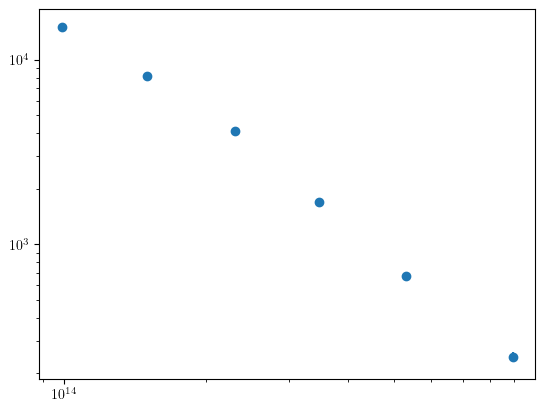

In [106]:
plt.errorbar(Mvirs, N_halos, yerr=np.sqrt(N_halos), fmt='o')
plt.yscale('log')
plt.xscale('log')

In [11]:
# compute # of galaxies in (R, r_los) bins and compare to sim number. 
n_gal = 0.014 # (Mpc/h)^-3
rmax = 40
rlos_edges = np.linspace(-rmax, rmax, int(rmax)+1)
rlos_cens = (rlos_edges[1:]+rlos_edges[:-1])/2.0

N_R_rlos = np.zeros((len(Mvirs), len(r_cens), len(rlos_cens)))
avg_N_R_rlos = np.zeros((len(Mvirs), len(r_cens), len(rlos_cens)))

R_widths = r_edges[1:] - r_edges[:-1]
rlos_widths = rlos_edges[1:] - rlos_edges[:-1]
R_grid, rlos_grid = np.meshgrid(r_cens, rlos_cens, indexing='ij')
bin_vols = 2 * np.pi * R_grid * R_widths[:, None] * rlos_widths[None, :]

with h5.File(vel_path, 'r') as hdf:
    for k, M in tqdm(enumerate(Mvirs)):
        rel_R = hdf[f'R/{str(k)}'][()]
        rel_rlos = hdf[f'rlos/{str(k)}'][()]
        
        N_R_rlos[k], _, _ = np.histogram2d(rel_R, rel_rlos, bins=[r_edges, rlos_edges], density=False)

        r_dist = np.sqrt(R_grid**2 + rlos_grid**2)
        avg_N_R_rlos[k] = n_gal * (1 + cf_inf(r_dist, M, cf_pars)) * bin_vols

0it [00:00, ?it/s]

6it [03:43, 37.31s/it] 


0.016664449048924283
0.020069649630594898
0.025155832007452184
0.037306343160654495
0.05352403133765254
0.09081361400887164


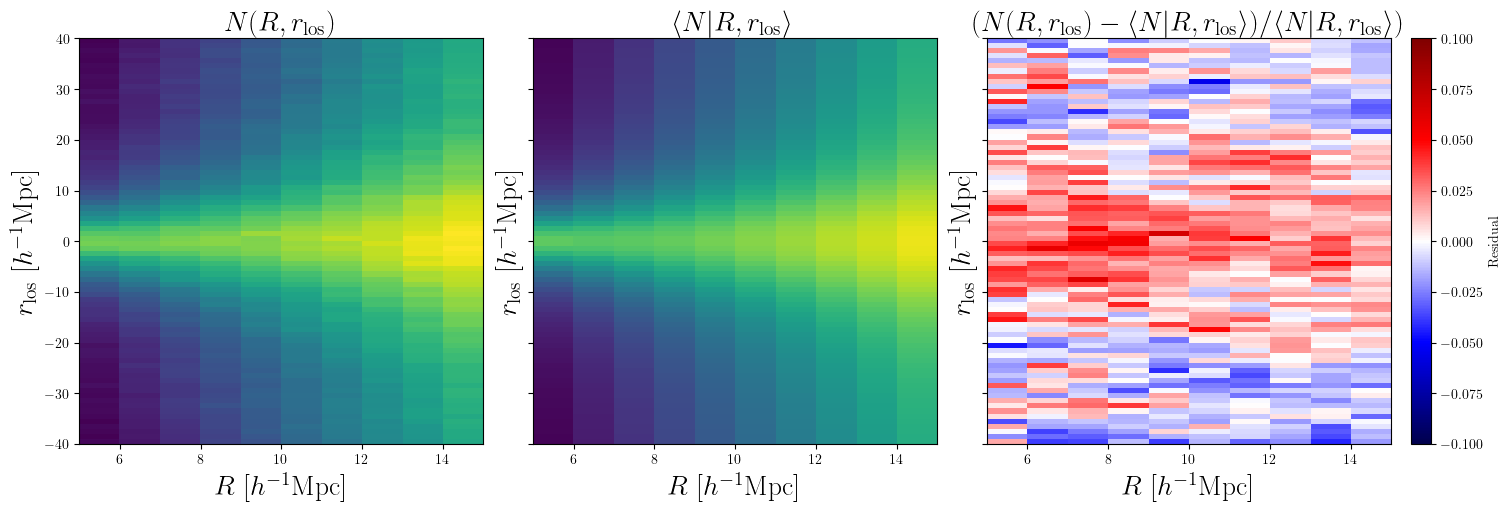

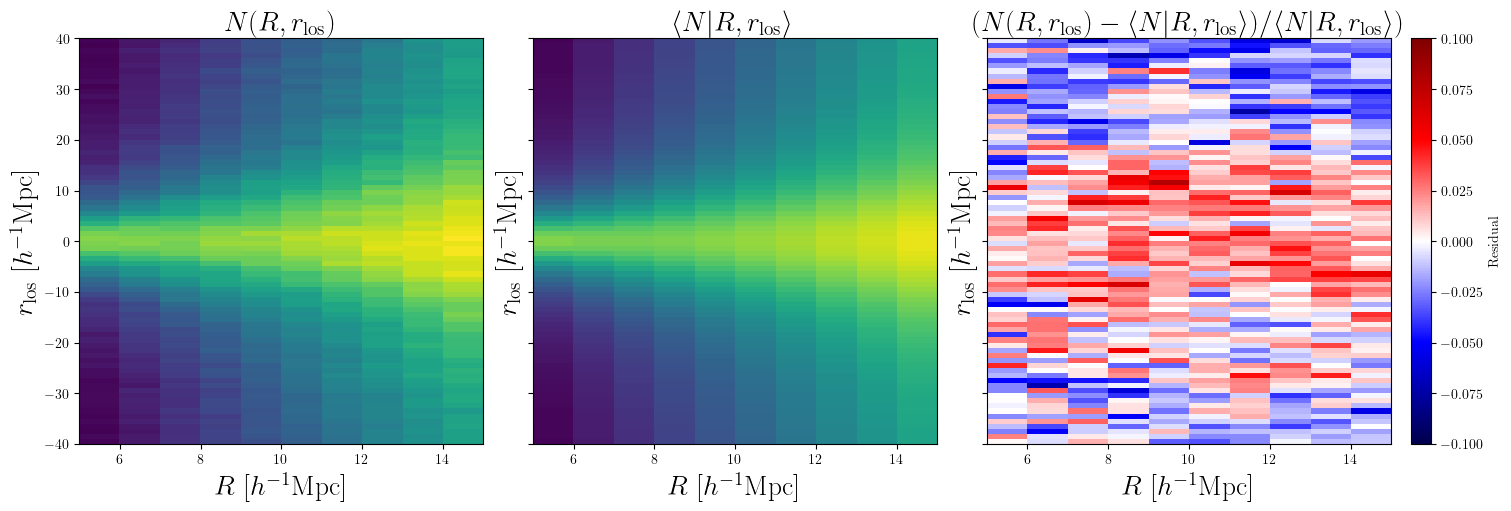

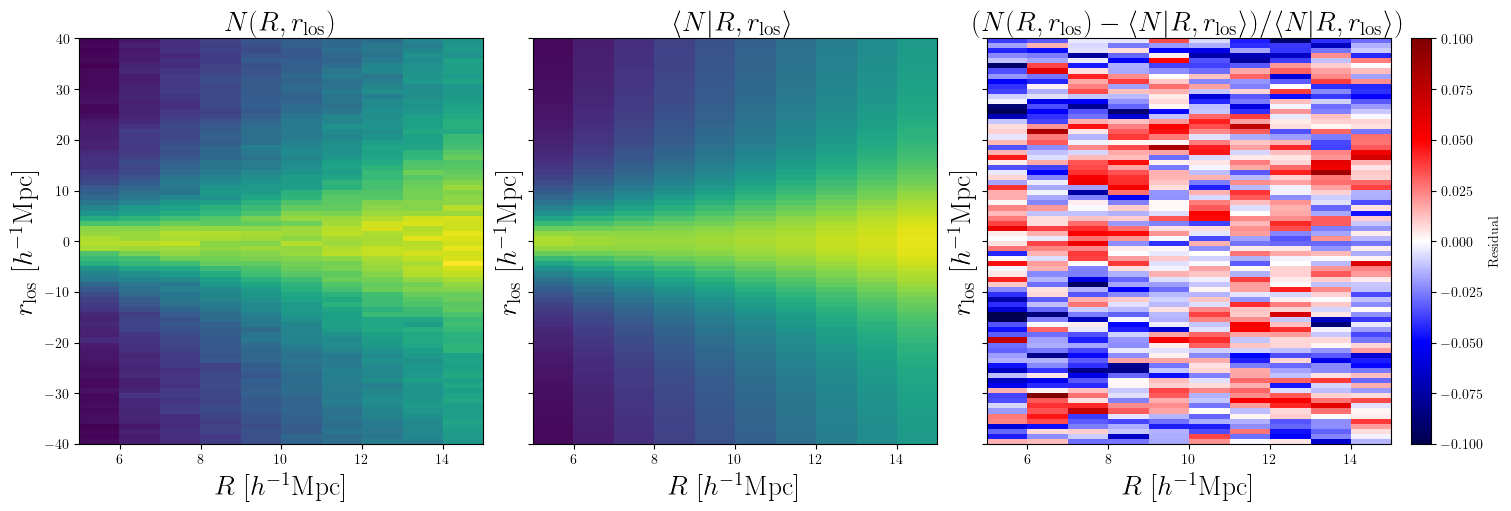

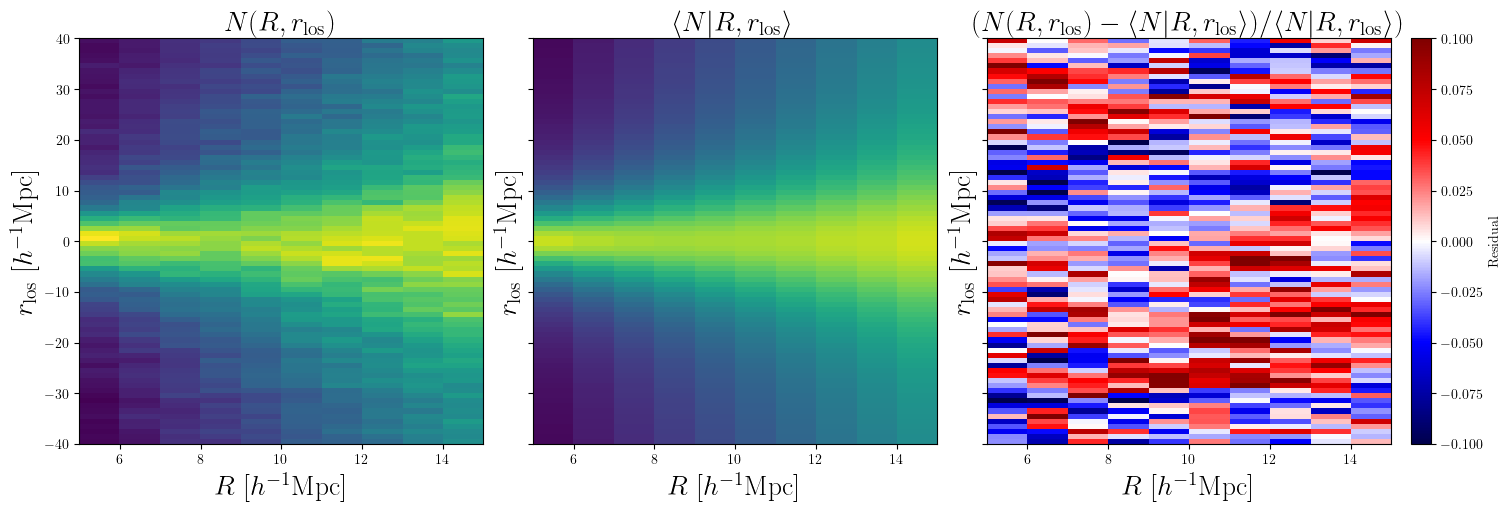

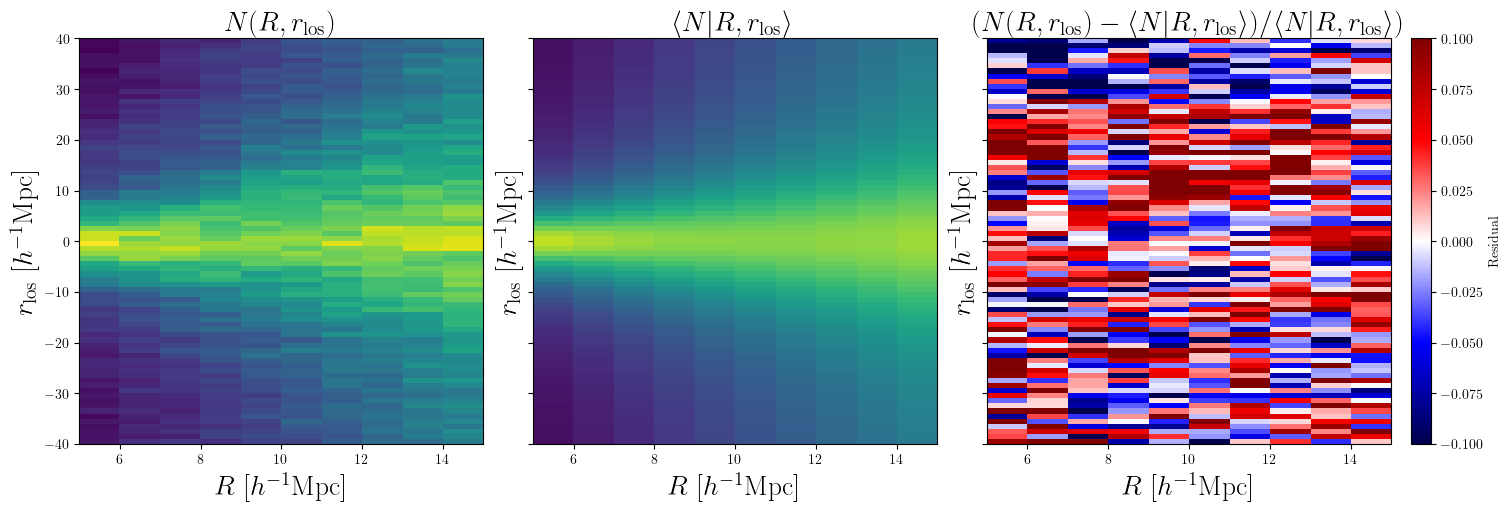

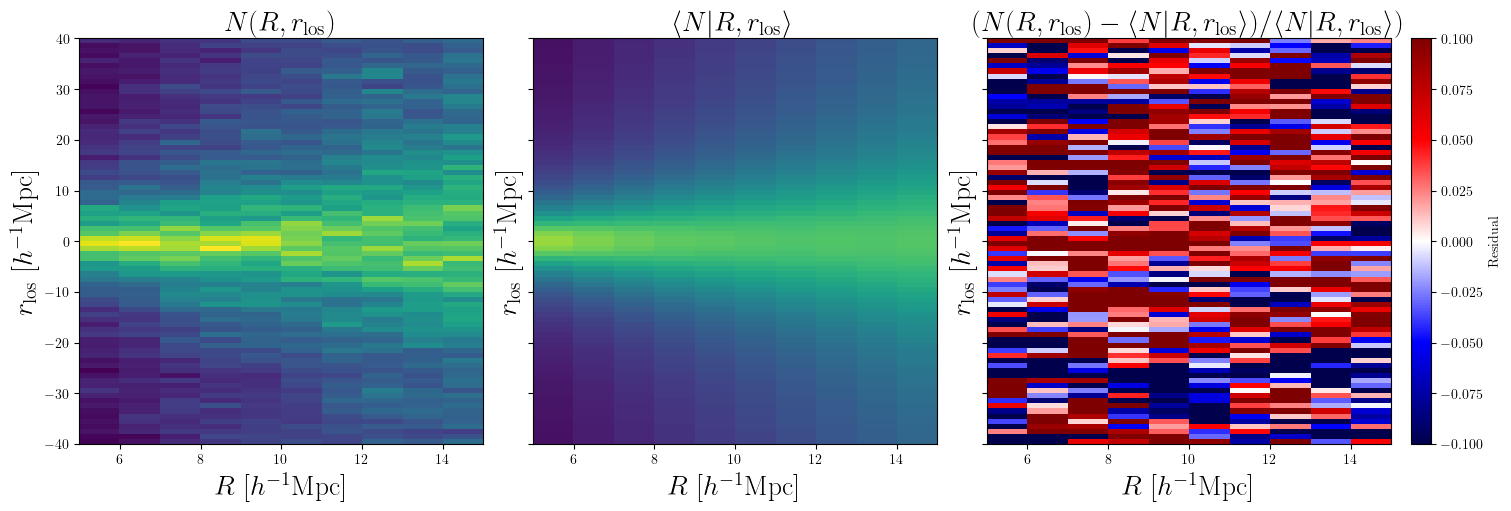

In [7]:

for k in range(len(Mvirs)):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5), layout='constrained', sharey='row')

    ax[0].imshow(N_R_rlos[k].T, origin='lower', aspect='auto', vmin=N_R_rlos[k].T.min(), vmax=N_R_rlos[k].T.max(),
                    extent=[r_edges[0], r_edges[-1], rlos_edges[0], rlos_edges[-1]])
    ax[0].set_xlabel(r'$R \ [h^{-1}$Mpc]', fontsize=20)
    ax[0].set_ylabel(r'$r_{\rm los} \ [h^{-1}$Mpc]', fontsize=20)
    ax[0].set_title(r'$N(R, r_{\rm los})$', fontsize=20)

    ax[1].imshow(N_halos[k]*avg_N_R_rlos[k].T, origin='lower', aspect='auto', vmin=N_R_rlos[k].T.min(), vmax=N_R_rlos[k].T.max(), 
                    extent=[r_edges[0], r_edges[-1], rlos_edges[0], rlos_edges[-1]])
    ax[1].set_xlabel(r'$R \ [h^{-1}$Mpc]', fontsize=20)
    ax[1].set_ylabel(r'$r_{\rm los} \ [h^{-1}$Mpc]', fontsize=20)
    ax[1].set_title(r'$\langle N | R, r_{\rm los}\rangle$', fontsize=20)

    res = (N_R_rlos[k]-N_halos[k]*avg_N_R_rlos[k]).T/(N_halos[k]*avg_N_R_rlos[k].T)
    im = ax[2].imshow(res, origin='lower', aspect='auto', cmap='seismic', vmax=0.1, vmin=-0.1, 
                         extent=[r_edges[0], r_edges[-1], rlos_edges[0], rlos_edges[-1]])
    ax[2].set_xlabel(r'$R \ [h^{-1}$Mpc]', fontsize=20)
    ax[2].set_ylabel(r'$r_{\rm los} \ [h^{-1}$Mpc]', fontsize=20)
    ax[2].set_title(r'$(N(R, r_{\rm los}) - \langle N | R, r_{\rm los} \rangle)/\langle N | R, r_{\rm los} \rangle)$', fontsize=20)
    plt.colorbar(im, ax=ax[2], label='Residual')

    print(np.mean(np.abs(res)))

285.98970300338397
188.64388631327037
117.51975191269622
77.73844647597863
46.45420475168321
30.857909584387524


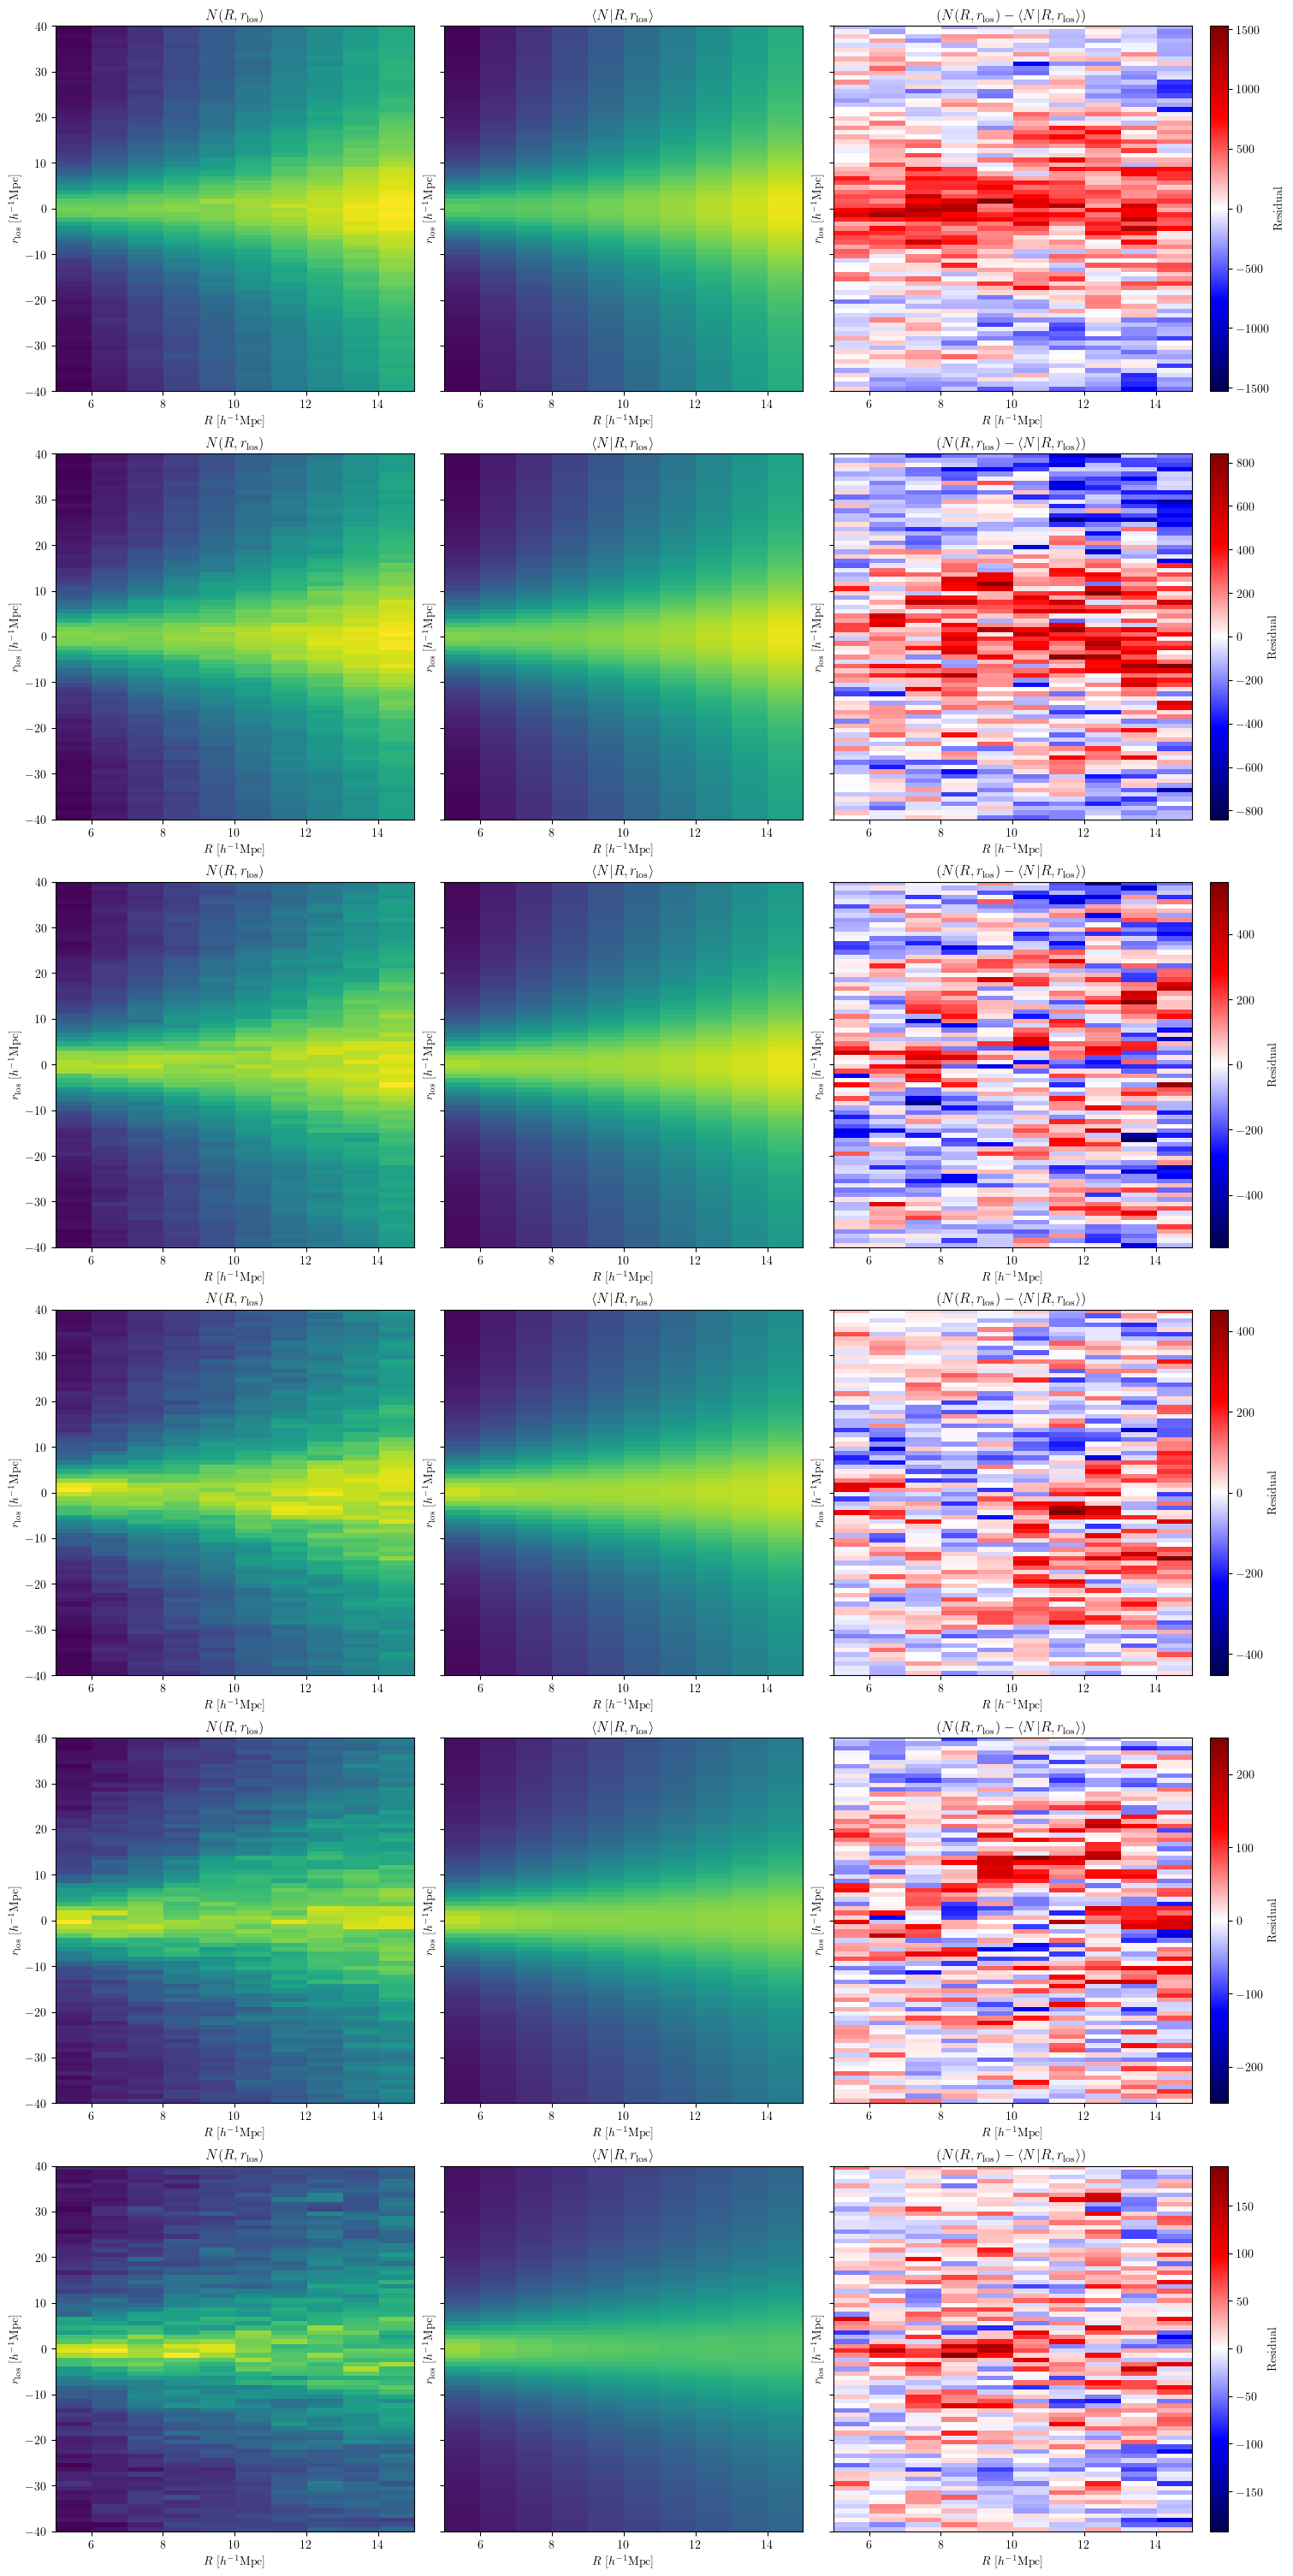

In [75]:
fig, ax = plt.subplots(len(Mvirs), 3, figsize=(15, len(Mvirs)*5), layout='constrained', sharey='row')

for k in range(len(Mvirs)):
    ax[k, 0].imshow(N_R_rlos[k].T, origin='lower', aspect='auto', vmin=N_R_rlos[k].T.min(), vmax=N_R_rlos[k].T.max(),
                    extent=[r_edges[0], r_edges[-1], rlos_edges[0], rlos_edges[-1]])
    ax[k, 0].set_xlabel(r'$R \ [h^{-1}$Mpc]')
    ax[k, 0].set_ylabel(r'$r_{\rm los} \ [h^{-1}$Mpc]')
    ax[k, 0].set_title(r'$N(R, r_{\rm los})$')

    ax[k, 1].imshow(N_halos[k]*avg_N_R_rlos[k].T, origin='lower', aspect='auto', vmin=N_R_rlos[k].T.min(), vmax=N_R_rlos[k].T.max(), 
                    extent=[r_edges[0], r_edges[-1], rlos_edges[0], rlos_edges[-1]])
    ax[k, 1].set_xlabel(r'$R \ [h^{-1}$Mpc]')
    ax[k, 1].set_ylabel(r'$r_{\rm los} \ [h^{-1}$Mpc]')
    ax[k, 1].set_title(r'$\langle N | R, r_{\rm los}\rangle$')

    res = (N_R_rlos[k]-N_halos[k]*avg_N_R_rlos[k]).T#/(N_halos[k]*avg_N_R_rlos[k].T)
    im = ax[k, 2].imshow(res, origin='lower', aspect='auto', cmap='seismic', vmax=np.max(np.abs(res)), vmin=-np.max(np.abs(res)), 
                         extent=[r_edges[0], r_edges[-1], rlos_edges[0], rlos_edges[-1]])
    ax[k, 2].set_xlabel(r'$R \ [h^{-1}$Mpc]')
    ax[k, 2].set_ylabel(r'$r_{\rm los} \ [h^{-1}$Mpc]')
    ax[k, 2].set_title(r'$(N(R, r_{\rm los}) - \langle N | R, r_{\rm los} \rangle)$')
    plt.colorbar(im, ax=ax[k, 2], label='Residual')

    print(np.mean(np.abs(res)))

In [8]:
N_R_rlos[k].shape

(10, 80)

In [23]:
mvirs = Mvirs/1e14

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4162472/2949018374.py:7: SyntaxWarning: invalid escape sequence '\s'
  ax[0].plot(rlos_cens, N_halos[k]*avg_N_R_rlos[k, i, :], label=f'$M\sim{mvirs[k]:.3}$')
/tmp/ipykernel_4162472/2949018374.py:20: SyntaxWarning: invalid escape sequence '\s'
  fig.suptitle(f"$R\sim{r_cens[i]}$")


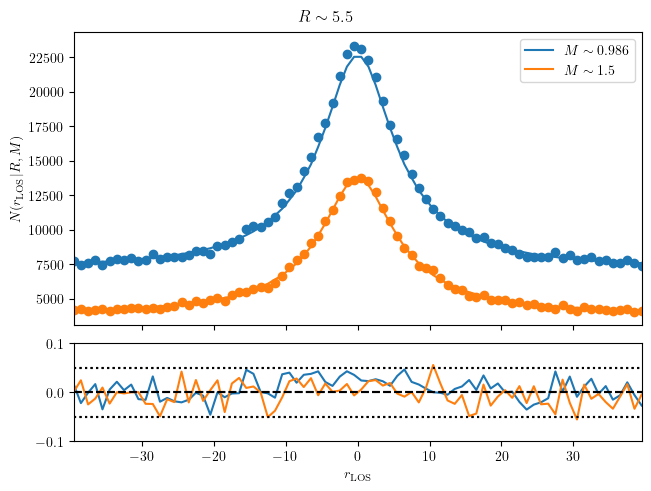

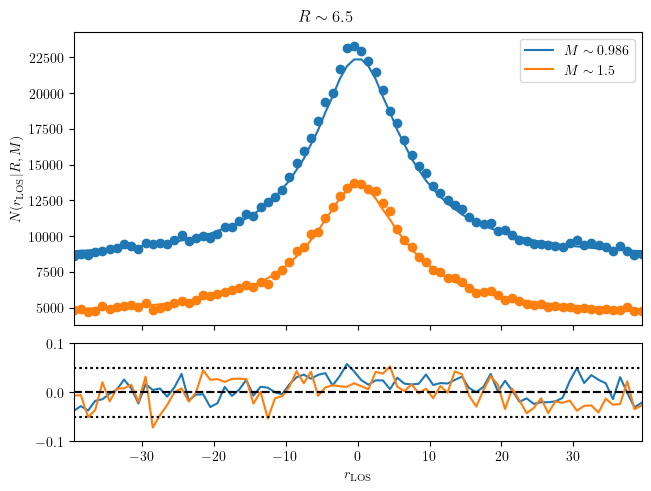

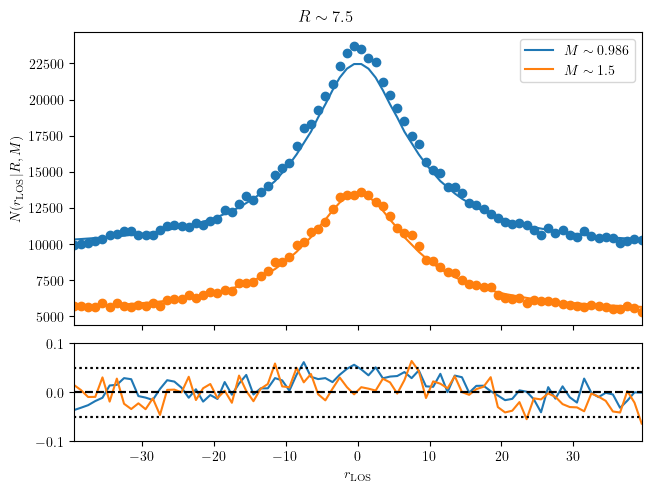

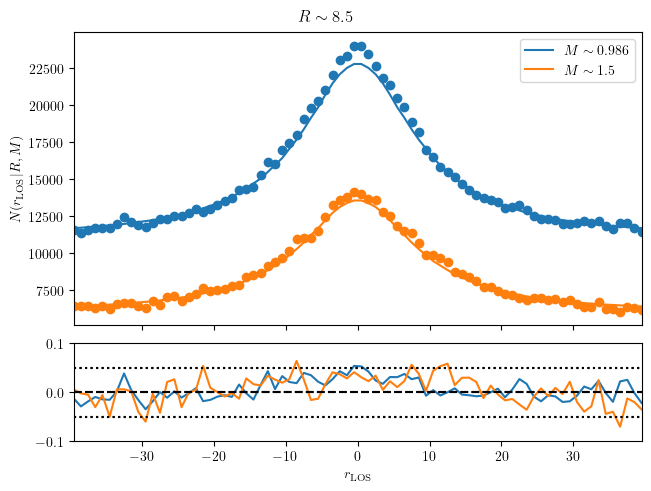

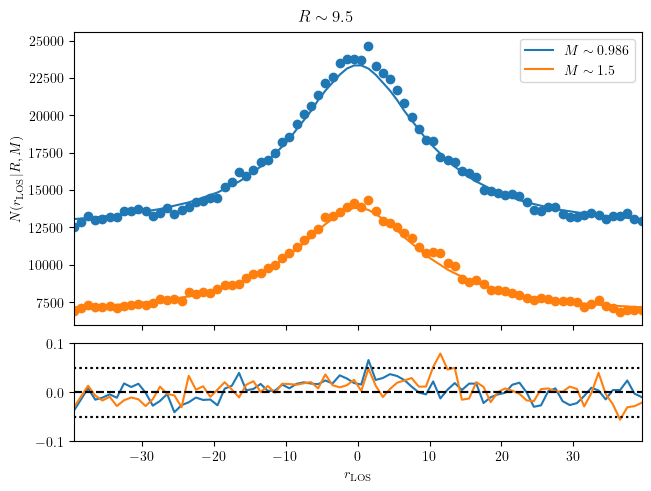

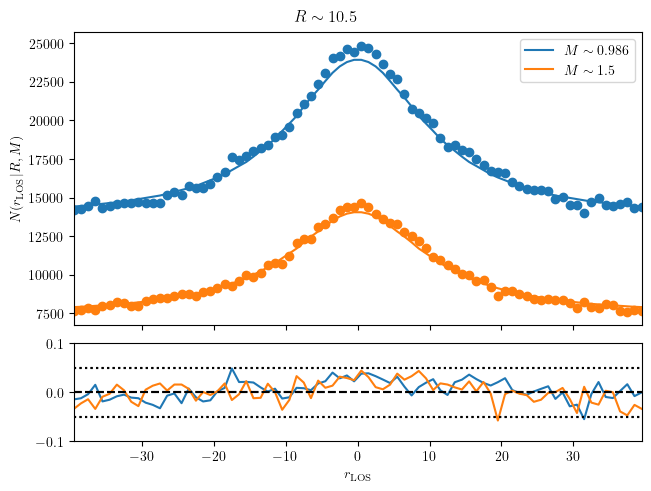

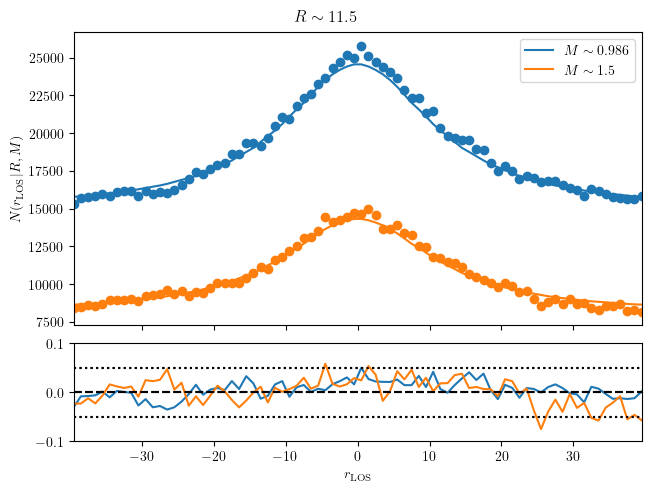

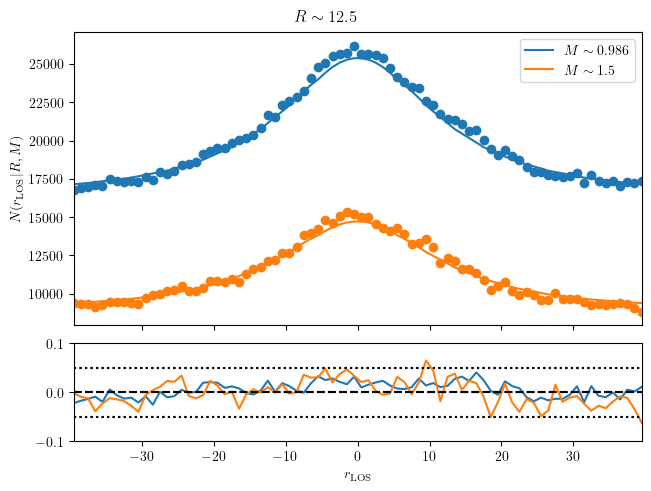

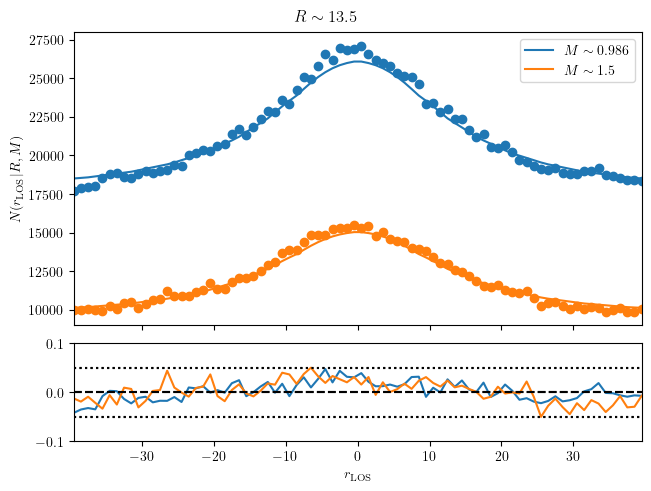

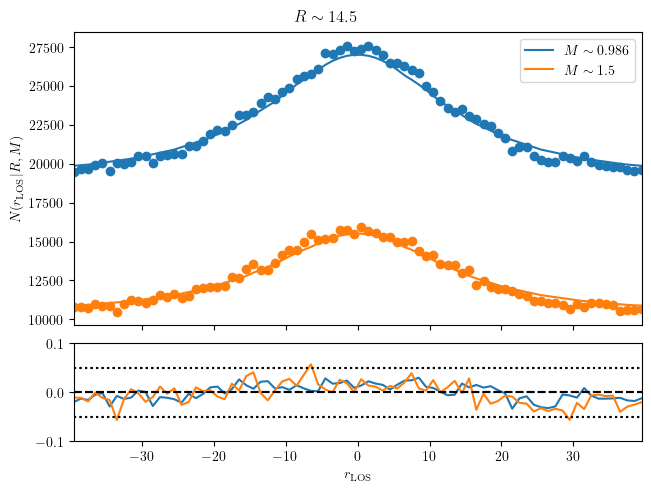

In [28]:
for i in range(len(r_cens)):
    fig, ax = plt.subplots(2, 1, layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})


    for k in range(len(Mvirs)//3):
        ax[0].scatter(rlos_cens, N_R_rlos[k, i, :])
        ax[0].plot(rlos_cens, N_halos[k]*avg_N_R_rlos[k, i, :], label=f'$M\sim{mvirs[k]:.3}$')

        ax[1].plot(rlos_cens, (N_R_rlos[k, i, :]- N_halos[k]*avg_N_R_rlos[k, i, :])/(N_halos[k]*avg_N_R_rlos[k, i, :]))
        ax[1].axhline(0, ls='--', c='k')
        ax[1].axhline(-0.05, ls=':', c='k')
        ax[1].axhline(0.05, ls=':', c='k')

    ax[0].legend(loc='upper right')
    ax[1].set_ylim((-0.1, 0.1))
    ax[1].margins(x=0)
    ax[0].margins(x=0)
    ax[1].set_xlabel(r'$r_{\rm LOS}$')
    ax[0].set_ylabel(r'$N(r_{\rm LOS}|R, M)$')
    fig.suptitle(f"$R\sim{r_cens[i]}$")

0.012429999015455773
0.014362534058456675
0.01288870899602525
0.019638184178473843
0.02736163196717508
0.04198130893079443


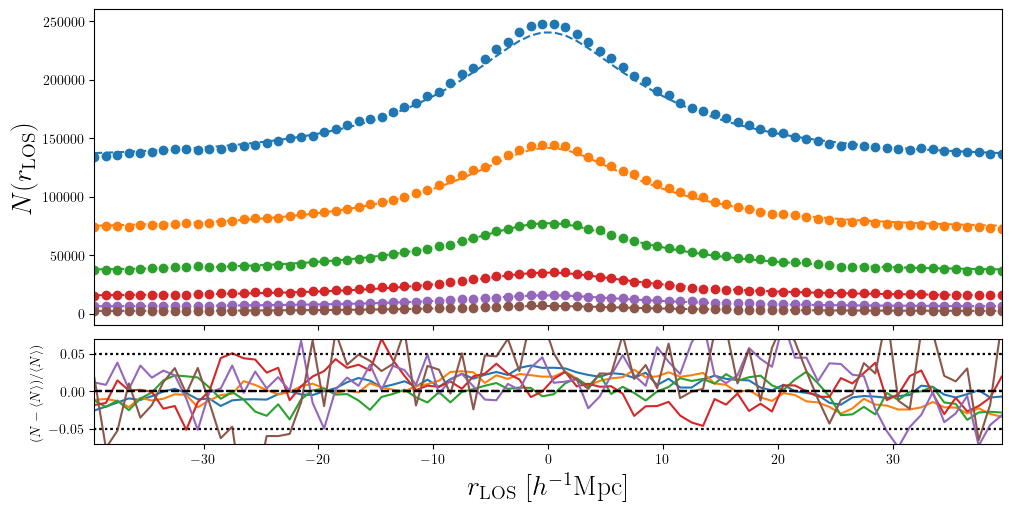

In [34]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})

for k in range(len(Mvirs)):

    ax[0].scatter(rlos_cens, np.sum(N_R_rlos[k], axis=0))
    #ax[0].set_xlabel(r'$R \ [h^{-1}$Mpc]', fontsize=20)
    ax[0].set_ylabel(r'$N(r_{\rm LOS})$', fontsize=20)

    ax[0].plot(rlos_cens, np.sum(N_halos[k]*avg_N_R_rlos[k], axis=0), ls='--', c=f'C{k}')
    #ax[0].set_yscale('log')
    #ax[1].set_xlabel(r'$R \ [h^{-1}$Mpc]', fontsize=20)
    #ax[1].set_ylabel(r'$\langle N | R, r_{\rm los}\rangle$', fontsize=20)

    res = (np.sum(N_R_rlos[k], axis=0)-np.sum(N_halos[k]*avg_N_R_rlos[k], axis=0))/np.sum(N_halos[k]*avg_N_R_rlos[k], axis=0)
    ax[1].plot(rlos_cens, res)
    ax[1].axhline(0, c='k', ls='--')
    ax[1].axhline(-0.05, c='k', ls=':', alpha=0.5) 
    ax[1].axhline(0.05, c='k', ls=':', alpha=0.5) 
    ax[1].set_xlabel(r'$r_{\rm LOS} \ [h^{-1}$Mpc]', fontsize=20)
    ax[1].set_ylabel(r'$(N - \langle N \rangle)/\langle N \rangle)$', fontsize=10)
    ax[1].set_ylim((-0.07, 0.07))

    print(np.mean(np.abs(res)))


ax[0].margins(x=0)
ax[1].margins(x=0)

0.012429999015455773
0.014362534058456675


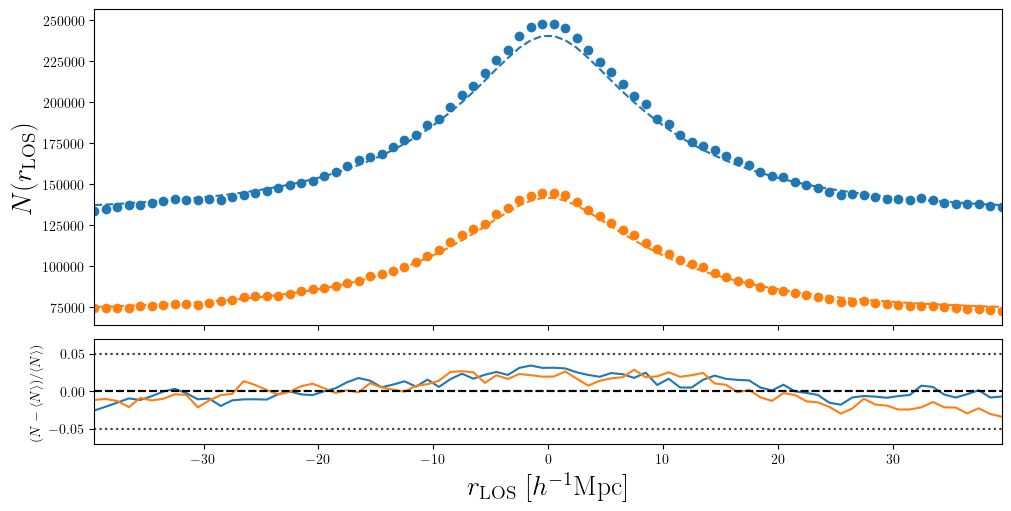

In [35]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})

for k in range(len(Mvirs)//3):

    ax[0].scatter(rlos_cens, np.sum(N_R_rlos[k], axis=0))
    #ax[0].set_xlabel(r'$R \ [h^{-1}$Mpc]', fontsize=20)
    ax[0].set_ylabel(r'$N(r_{\rm LOS})$', fontsize=20)

    ax[0].plot(rlos_cens, np.sum(N_halos[k]*avg_N_R_rlos[k], axis=0), ls='--', c=f'C{k}')
    #ax[0].set_yscale('log')
    #ax[1].set_xlabel(r'$R \ [h^{-1}$Mpc]', fontsize=20)
    #ax[1].set_ylabel(r'$\langle N | R, r_{\rm los}\rangle$', fontsize=20)

    res = (np.sum(N_R_rlos[k], axis=0)-np.sum(N_halos[k]*avg_N_R_rlos[k], axis=0))/np.sum(N_halos[k]*avg_N_R_rlos[k], axis=0)
    ax[1].plot(rlos_cens, res)
    ax[1].axhline(0, c='k', ls='--')
    ax[1].axhline(-0.05, c='k', ls=':', alpha=0.5) 
    ax[1].axhline(0.05, c='k', ls=':', alpha=0.5) 
    ax[1].set_xlabel(r'$r_{\rm LOS} \ [h^{-1}$Mpc]', fontsize=20)
    ax[1].set_ylabel(r'$(N - \langle N \rangle)/\langle N \rangle)$', fontsize=10)
    ax[1].set_ylim((-0.07, 0.07))

    print(np.mean(np.abs(res)))


ax[0].margins(x=0)
ax[1].margins(x=0)

In [39]:
np.sum(N_halos[:, None, None]*avg_N_R_rlos, axis=0).shape

(10, 80)

0.010968308645030705


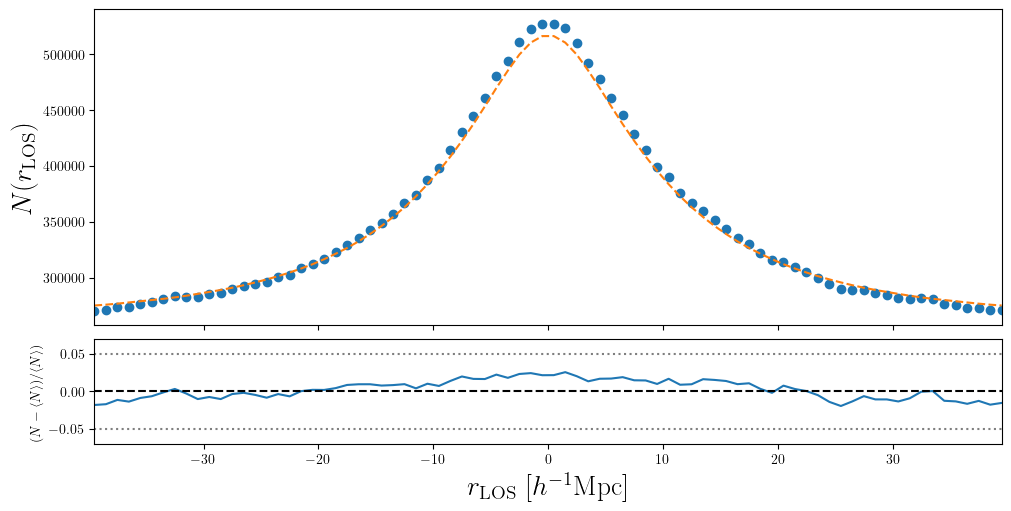

In [40]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})

ax[0].scatter(rlos_cens, np.sum(np.sum(N_R_rlos, axis=0), axis=0))
ax[0].set_ylabel(r'$N(r_{\rm LOS})$', fontsize=20)

ax[0].plot(rlos_cens, np.sum(np.sum(N_halos[:, None, None]*avg_N_R_rlos, axis=0), axis=0), ls='--', c=f'C{k}')

res = (np.sum(np.sum(N_R_rlos, axis=0), axis=0)-np.sum(np.sum(N_halos[:, None, None]*avg_N_R_rlos, axis=0), axis=0))/np.sum(np.sum(N_halos[:, None, None]*avg_N_R_rlos, axis=0), axis=0)
ax[1].plot(rlos_cens, res)
ax[1].axhline(0, c='k', ls='--')
ax[1].axhline(-0.05, c='k', ls=':', alpha=0.5) 
ax[1].axhline(0.05, c='k', ls=':', alpha=0.5) 
ax[1].set_xlabel(r'$r_{\rm LOS} \ [h^{-1}$Mpc]', fontsize=20)
ax[1].set_ylabel(r'$(N - \langle N \rangle)/\langle N \rangle)$', fontsize=10)
ax[1].set_ylim((-0.07, 0.07))

print(np.mean(np.abs(res)))

ax[0].margins(x=0)
ax[1].margins(x=0)

0.008016844691441514
0.0035562424043025205
0.002917745508675312
0.006512124238462083
0.01295390907484959
0.022639203828862642


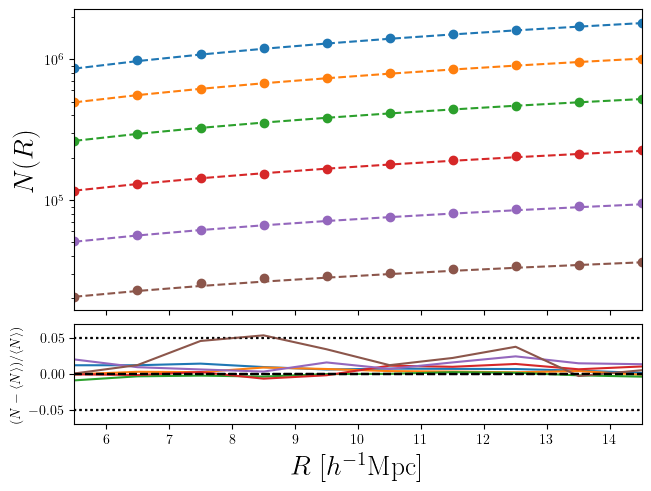

In [103]:
fig, ax = plt.subplots(2, 1, layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})

for k in range(len(Mvirs)):

    ax[0].scatter(r_cens, np.sum(N_R_rlos[k], axis=1))
    #ax[0].set_xlabel(r'$R \ [h^{-1}$Mpc]', fontsize=20)
    ax[0].set_ylabel(r'$N(R)$', fontsize=20)

    ax[0].plot(r_cens, np.sum(N_halos[k]*avg_N_R_rlos[k], axis=1), ls='--', c=f'C{k}')
    ax[0].set_yscale('log')
    #ax[1].set_xlabel(r'$R \ [h^{-1}$Mpc]', fontsize=20)
    #ax[1].set_ylabel(r'$\langle N | R, r_{\rm los}\rangle$', fontsize=20)

    res = (np.sum(N_R_rlos[k], axis=1)-np.sum(N_halos[k]*avg_N_R_rlos[k], axis=1))/np.sum(N_halos[k]*avg_N_R_rlos[k], axis=1)
    ax[1].plot(r_cens, res)
    ax[1].axhline(0, c='k', ls='--')
    ax[1].axhline(-0.05, c='k', ls=':', alpha=0.5) 
    ax[1].axhline(0.05, c='k', ls=':', alpha=0.5) 
    ax[1].set_xlabel(r'$R \ [h^{-1}$Mpc]', fontsize=20)
    ax[1].set_ylabel(r'$(N - \langle N \rangle)/\langle N \rangle)$', fontsize=10)
    ax[1].set_ylim((-0.07, 0.07))

    print(np.mean(np.abs(res)))


ax[0].margins(x=0)
ax[1].margins(x=0)

In [6]:
r_fine_edges = np.linspace(5, 50, 100)
r_fine_cens = 0.5*(r_fine_edges[1:]+r_fine_edges[:-1])

rho_RM = np.zeros((6, len(r_fine_cens)))

with h5.File(vel_path, 'r') as hdf:

    for k in range(len(Mvirs)):
        
        rs = hdf[f'r/{str(k)}'][()]

        for j in range(len(r_fine_cens)):
            
            r_mask = (rs >= r_fine_edges[j])&(rs <= r_fine_edges[j+1])

            N_pairs = r_mask.sum()

            V_shell = 4/3 *  np.pi * ( r_fine_edges[j+1]**3 - r_fine_edges[j]**3 ) 

            rho = N_pairs / N_halos[k] / V_shell 

            rho_RM[k, j] = rho

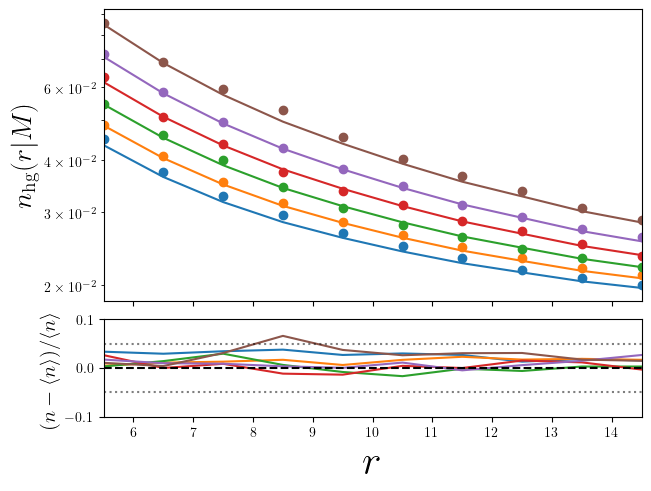

In [102]:
fig, ax = plt.subplots(2, 1, layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})

for k in range(len(Mvirs)):
    rho = n_gal*(1+cf_inf(r_cens, Mvirs[k], cf_pars)) 
    ax[0].scatter(r_cens, rho_RM[k], label=r'MDPL2')
    ax[0].plot(r_cens, rho, label=r'MAP Model')

    ax[1].plot(r_cens, (rho_RM[k] - rho)/rho)


ax[0].set_yscale('log')
#ax[0].set_xscale('log')

ax[1].axhline(0, c='k', ls='--') 
ax[1].axhline(-0.05, c='k', ls=':', alpha=0.5) 
ax[1].axhline(0.05, c='k', ls=':', alpha=0.5) 

#ax[1].set_xscale('log')
ax[1].set_ylim((-0.1, 0.1))

ax[0].set_ylabel(r'$n_{\rm hg}(r|M)$', fontsize=20)
ax[1].set_ylabel(r'$(n - \langle n \rangle )/\langle n \rangle$', fontsize=15)
ax[1].set_xlabel(r'$r$', fontsize=30)

ax[0].margins(x=0)
ax[1].margins(x=0)

In [8]:
# sample using model rather than sim

def sample_rlos_from_density_profile(N, R_cen, M, rho_model, rlos_max=50.0):
    """
    Generate rlos samples following the marginalized density profile.
    
    Parameters:
    -----------
    N : int
        Number of samples to generate
    R_cen : float
        Projected separation R
    M : float
        Halo mass
    rho_model : callable
        Function rho(r, M) giving number density at 3D distance r
    rlos_max : float
        Maximum line-of-sight distance to consider (symmetric: -rlos_max to +rlos_max)
    
    Returns:
    --------
    rlos_samples : array
        Samples of line-of-sight distances
    """
    # The marginalized probability for rlos at fixed R is:
    # P(rlos|R, M) ∝ rho(r|M) where r = sqrt(R^2 + rlos^2)
    
    # Create a grid spanning negative to positive rlos
    rlos_grid = np.linspace(-rlos_max, rlos_max, 2000)
    r_grid = np.sqrt(R_cen**2 + rlos_grid**2)
    
    # Evaluate density at all grid points
    pdf_vals = rho_model(r_grid, M)
    
    # Normalize to get PDF (integrate over rlos from -rlos_max to +rlos_max)
    pdf_vals = pdf_vals / np.trapz(pdf_vals, rlos_grid)
    
    # Compute CDF
    cdf_vals = np.concatenate([[0], np.cumsum(0.5 * (pdf_vals[1:] + pdf_vals[:-1]) * 
                                                np.diff(rlos_grid))])
    
    # Generate uniform random numbers
    u = np.random.uniform(0, 1, N)
    
    # Inverse transform sampling via interpolation
    rlos_samples = np.interp(u, cdf_vals, rlos_grid)
    
    return rlos_samples


def joint_dist_samples(N, r, M, pars):
    """Optimized version with vectorization and pre-computation.
    
    Args:
        N: Number of samples to generate (should equal len(r) for vectorized case)
        r: Radial distance(s) - scalar or array
        M: Mass
        pars: Model parameters
    """
    
    vrpp, vrps, vrsp, vrss, srpp, srps, srsp, srss, delta_m, delta_b, \
        A, Bp, Bs, mu0p, mu0c, mu1p, mu1c, C1p, C1c = pars

    # Vectorize if r is an array
    r = np.atleast_1d(r)
    n_r = r.shape[0]
    
    # For proper vectorization, N should equal n_r
    if N != n_r:
        # Fall back to generating N samples for a single r value
        if n_r == 1:
            r = np.repeat(r, N)
            n_r = N
        else:
            raise ValueError(f"N ({N}) must equal len(r) ({n_r}) for vectorized operation")
    
    # Mass dependence (vectorized)
    M_pivot = 1e14
    m = M / M_pivot
    
    vr_p = -plaw(m, vrpp, vrps)
    vr_s = -plaw(m, vrsp, vrss)
    sr_p = plaw(m, srpp, srps)
    sr_s = -plaw(m, srsp, srss)
    
    r_pivot = 10
    sr_0 = 213027
    
    # Vectorized radial dependence
    r_ratio = r / r_pivot
    peak = plaw(r_ratio, vr_p, vr_s)
    variance = plaw(r_ratio, sr_p, sr_s) + sr_0
    
    # Vectorized interpolation - handle output correctly
    stacked_input = np.column_stack([peak, variance])
    xi_output = xi_RBF(stacked_input)
    lam_output = lam_RBF(stacked_input)
    
    # Handle different possible output formats from RBF
    if isinstance(xi_output, tuple):
        xi = xi_output[0]
    else:
        xi = xi_output
    
    if isinstance(lam_output, tuple):
        lam = lam_output[0]
    else:
        lam = lam_output
    
    # Ensure 1D arrays
    xi = np.atleast_1d(xi).ravel()
    lam = np.atleast_1d(lam).ravel()
    
    # Vectorized JSU parameters
    gam = 0.00111 * xi + 0.71
    delt = 0.0022 * lam + line(m, delta_m, delta_b)
    
    # Generate one radial sample per r value
    rad_samples = np.array([
        johnsonsu.rvs(a=gam[i], b=delt[i], loc=xi[i], scale=lam[i], size=1)[0]
        for i in range(n_r)
    ])
    
    mask = np.abs(rad_samples) < 3000
    
    # Pre-compute constants
    dof = 5
    r_C = 48
    C0 = 105_000
    
    # Vectorized mass dependence
    B = plaw(m, Bp, Bs)
    mu0 = plaw(m, mu0p, 1) + mu0c
    mu1 = plaw(m, mu1p, 1) + mu1c
    C1 = plaw(m, C1p, 1) + C1c
    
    # Vectorized mu and C calculation
    mu = mu0 / r + mu1  # Shape: (n_r,)
    C = C1 * (r - r_C) + C0  # Shape: (n_r,)
    
    # Vectorized variance calculation - NO LOOPS!
    threshold = mu - 1000  # Shape: (n_r,)
    
    # Element-wise comparison
    above_threshold = rad_samples > threshold  # Shape: (n_r,)
    
    # Calculate variance for all samples at once
    diff = rad_samples - mu  # Shape: (n_r,)
    variance_above = A * diff**3 + B * diff**2 + C
    
    # Pre-compute slope and intercept for linear extrapolation (vectorized)
    vr0 = mu - 1000
    vr2 = mu - 998  # Small offset for numerical stability
    
    sig0 = A * (vr0 - mu)**3 + B * (vr0 - mu)**2 + C
    sig2 = A * (vr2 - mu)**3 + B * (vr2 - mu)**2 + C
    
    slope = (sig0 - sig2) / (vr0 - vr2)  # Shape: (n_r,)
    intercept = sig0 - slope * vr0  # Shape: (n_r,)
    
    # Linear extrapolation for below threshold
    variance_below = slope * rad_samples + intercept
    
    # Combine using boolean indexing
    variance = np.where(above_threshold, variance_above, variance_below)
    
    # Ensure non-negative variance
    variance = np.maximum(variance, 1e-6)
    scale = np.sqrt(variance)
    
    # Generate tangential samples (one per r value)
    tan_samples = t.rvs(df=dof, scale=scale, size=n_r)
    
    return rad_samples, tan_samples, mask

def P_vphys_R_samples(ind, m_ind, R_cens, rlos_vals):
    index = ind + m_ind*len(R_cens)

    samp_rlos = rlos_vals[index]

    r_distances = np.sqrt(R_cens[ind]**2 + samp_rlos**2)

    rad_samps, tan_samps, _ = joint_dist_samples(
        N=len(r_distances), 
        r=r_distances, 
        M=Mvirs[m_ind], 
        pars=joint_MAP
    )

    # Stack 
    samp_vr_vt = np.stack([rad_samps, tan_samps], axis=1)[:, :, np.newaxis]

    h = cosmo.h 
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)
    theta = np.arctan2(samp_rlos, R_cens[ind]) 

    cos = np.cos(theta)
    sin = np.sin(theta)

    vpeclos_samp =  samp_vr_vt[:, 0, 0]*sin + samp_vr_vt[:, 1, 0]*cos 

    vphyslos_samp = vpeclos_samp + a*H*samp_rlos / h 

    return vphyslos_samp

In [9]:
# generate rlos samples

rlos_model = []

for k in range(len(Mvirs)):
    N_samples = np.sum(N_halos[k]*avg_N_R_rlos[k], axis=1)
    for i in range(len(r_cens)):

        rlos_samps = sample_rlos_from_density_profile(N=int(N_samples[i]), R_cen=r_cens[i], M=Mvirs[k], rho_model=lambda r, M: n_gal*(1+cf_inf(r, M, cf_pars)), rlos_max=40.0)

        rlos_model.append(rlos_samps)

/tmp/ipykernel_152012/3791100970.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_vals = pdf_vals / np.trapz(pdf_vals, rlos_grid)


493852.0 494237.0


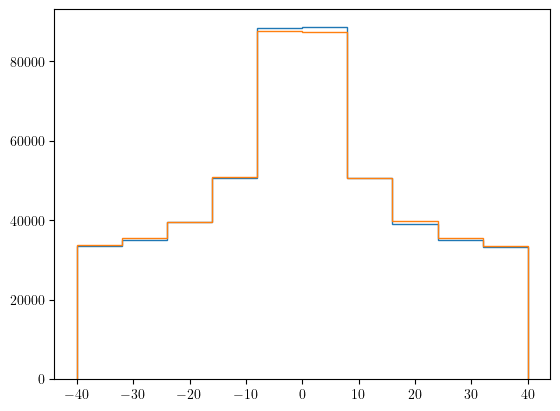

In [123]:
h1, _, _ = plt.hist(rlos_ls[10], range=[-40, 40], histtype='step')
h2, _, _ = plt.hist(rlos_model[10], histtype='step')

print(np.sum(h1), np.sum(h2))

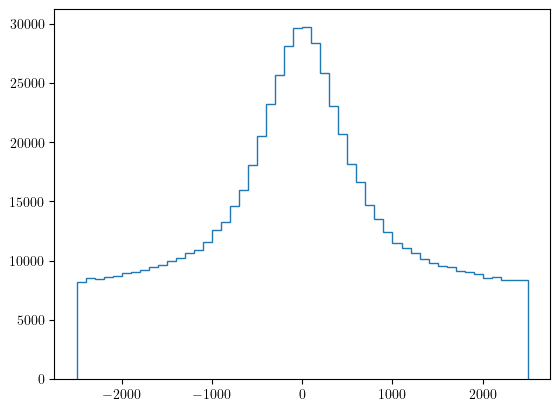

In [13]:
# check single bin, if slow
model_samples = P_vphys_R_samples(0, 0, r_cens, rlos_model)

hist, _, _ = plt.hist(model_samples, range=[-2500, 2500], bins=50, histtype='step')

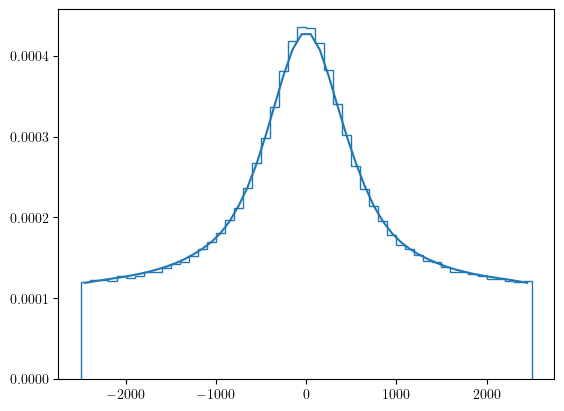

In [15]:
#hist, _, _ = plt.hist(model_samples, range=[-2500, 2500], bins=50, histtype='step', density=True)
hist2, vbins, _ = plt.hist(vphyslos_bin[0], range=[-2500, 2500], bins=50, histtype='step', density=True) 
vcens = (vbins[1:]+vbins[:-1])/2.0

model = P_vphys_R(vcens, r_cens[0], Mvirs[0], joint_MAP)

plt.plot(vcens, model, c='C0')
#plt.yscale('log')

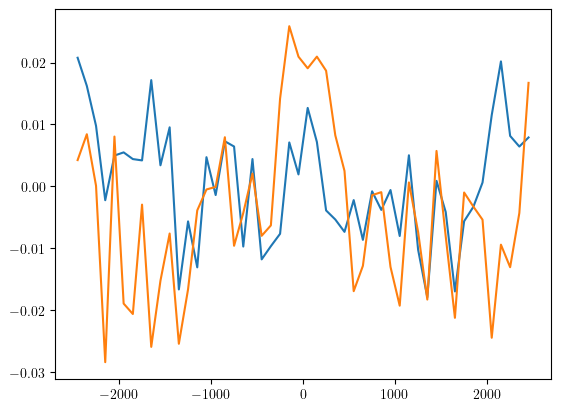

In [137]:
plt.plot(vcens, (hist - model)/model)
plt.plot(vcens, (hist2 - model)/model)

In [130]:
print(np.sum(hist), np.sum(hist2))

687788.0 698686.0


In [12]:
path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_M_grid_R_5_15_gal.npy'

P_vlos_grid = np.load(path)

Mvals = np.logspace(np.log10(0.5), np.log10(11), 100) 

In [16]:
from scipy.interpolate import interp1d, RegularGridInterpolator, UnivariateSpline

# Create the interpolator
interpolator = RegularGridInterpolator(
    (vcens, r_cens, Mvals[5:]), #Mvals[30:88]
    P_vlos_grid[:, :, 5:],
    method='cubic',  # or 'linear', 'quintic'
    bounds_error=False,
    fill_value=None  # or 0, np.nan
)

In [27]:
def P_vphys_R_int(M):
    v_mesh, R_mesh = np.meshgrid(vcens, r_cens, indexing='ij')
    points = np.stack([v_mesh.ravel(), R_mesh.ravel(), 
                    np.full(v_mesh.size, M)], axis=1)

    # Evaluate mdoel
    vals = interpolator(points).reshape(len(vcens), len(r_cens))

    return vals 

def RG_llh_ind(pars, data, r_ind):
    M, s = pars 

    dv = (vbins[-1]-vbins[0])/(len(vbins)-1)

    dist = P_vphys_R_int(M)[:, r_ind]
    dist = dist / np.sum(dist*dv)

    N_avg = np.sum(data) * dist * dv

    sigmasq = N_avg + s**2 * N_avg**2

    chisq = ((data) - N_avg)**2 / sigmasq  

    return - 0.5 * np.sum(chisq + np.log(sigmasq))

def RG_llh_sim(pars, data):
    M1, M2, M3, M4, M5, M6 = pars 

    Ms = np.array([M1, M2, M3, M4, M5, M6])

    dv = (vbins[-1]-vbins[0])/(len(vbins)-1)

    norm_model = np.zeros(data.shape)

    for k, M in enumerate(Ms):
        model = P_vphys_R_int(M) 
        norm_model[:, k, :] =  model / np.sum(model*dv, axis=0)

    N_avg = np.sum(data, axis=0) * norm_model * dv 

    sigmasq = N_avg #+ s**2 * N_avg**2 

    chisq = ((data) - N_avg)**2 / sigmasq  

    return - 0.5 * np.sum(chisq + np.log(sigmasq)) 


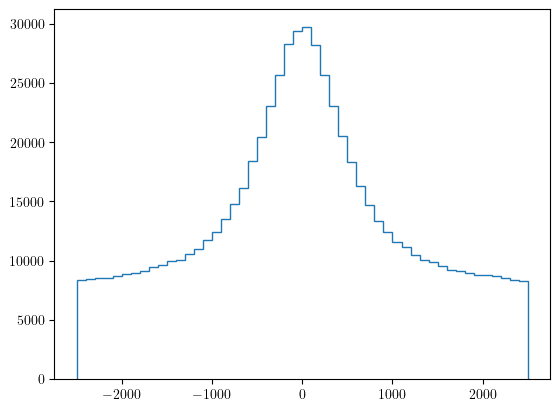

In [ ]:
hist, _, _ = plt.hist(model_samples, range=[-2500, 2500], bins=50, histtype='step', density=False)

In [11]:
# test: LLH as fcn of mass for some test bin

i = 5
#k = 1
j = 1

for k in range(len(Mvirs)):
    llhs = np.array([-RG_llh_ind([Mvals[m], 0], data=LOS_hists_bin[:, k, i], r_ind = i) for m in range(len(Mvals))])

    plt.plot(Mvals, llhs)
    plt.axvline(mvirs[k], c=f'C{k}')
    #plt.axvline(par_mass_ind[j, k, i, 0], ls='--', c=f'C{k}')
    plt.axvline(Mvals[np.argmin(llhs[~np.isnan(llhs)])], ls=':', c=f'C{k}')

plt.xscale('log')
plt.yscale('log')

NameError: name 'Mvals' is not defined

In [145]:
mvirs = Mvirs/1e14

p_init = [mvirs[0], 0.01]#[Mvirs[0]/1e14, 0.1]

i = 0

soln = scipy.optimize.minimize(lambda p: -RG_llh_ind(p, hist, i), p_init, 
                            bounds = [(0.5, 20.0), (0, 10)], #(0, np.inf), (0, np.inf), (0, np.inf)], 
                            method='nelder-mead', 
                            )

print("Initial: ", p_init) 
print("MLE: ", soln.x) 
print(soln.message)

Initial:  [np.float32(0.98642004), 0.01]
MLE:  [9.20427548e-01 1.89479683e-05]
Optimization terminated successfully.


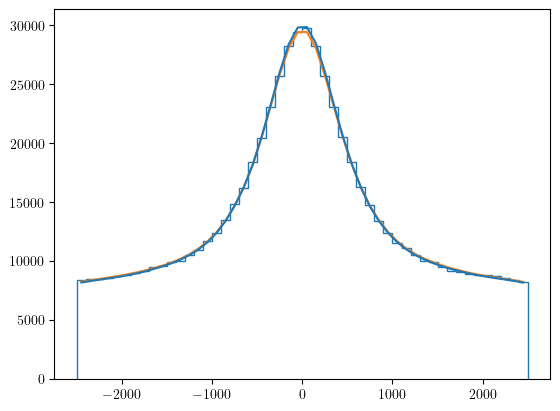

In [149]:
hist, _, _ = plt.hist(model_samples, range=[-2500, 2500], bins=50, histtype='step', density=False)

mod1 = P_vphys_R_int(soln.x[0])[:, 0]*np.sum(hist)*(vcens[1]-vcens[0])
mod2 = P_vphys_R_int(mvirs[0])[:, 0]*np.sum(hist)*(vcens[1]-vcens[0])
plt.plot(vcens, mod1, c='C1')
plt.plot(vcens, mod2, c='C0')

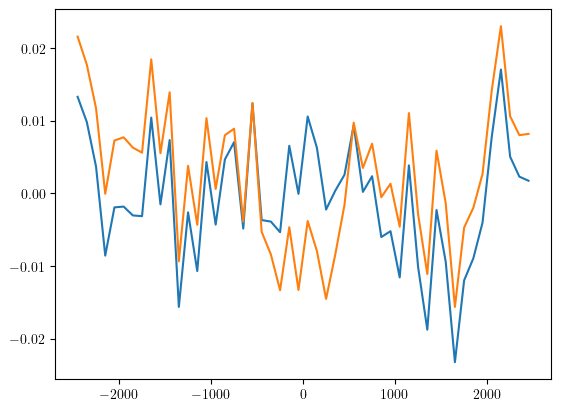

In [151]:
plt.plot(vcens, (hist - mod1)/mod1)
plt.plot(vcens, (hist - mod2)/mod2)

In [147]:
(soln.x[0]-mvirs[0])/mvirs[0]

np.float64(-0.06690100096166542)

In [17]:
# bin model samples computed with model density
samp_dens_path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_models/gal_model_bin_mass_samples_r_5_15_model_dens.hdf5'

vphyslos_dens = []

for k, M in enumerate(Mvirs):
    for i, R in enumerate(r_cens):
        with h5.File(samp_dens_path, 'r') as hdf:
            vphys = hdf[f'vphyslos/{str(k)}/{str(i)}'][()] 

        vphyslos_dens.append(vphys)


# bin data
bin_num = len(vcens)
LOS_hists_dens = np.zeros((bin_num, len(Mvirs), len(r_cens)))

for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        index = i + len(r_cens)*k

        hist, v_edges = np.histogram(vphyslos_dens[index], bins=bin_num, range=[-2500, 2500], density=False)
        #hist_bin, v_edges = np.histogram(vphyslos_bin[index], bins=bin_num, range=[-2500, 2500], density=False)
 #       hist_ind, v_edges = np.histogram(vphyslos_ind[index], bins=bin_num, range=[-2500, 2500], density=False)

        v_cens = (v_edges[:-1] + v_edges[1:]) / 2 

        LOS_hists_dens[:, k, i] = hist  
        #LOS_hists_bin[:, k, i] = hist_bin 

In [19]:
# MLE, all mass and individual radial bins
mvirs = Mvirs/1e14

par_mass_ind = np.zeros((len(mvirs), len(r_cens), 2))
err_mass_ind = np.zeros((len(mvirs), len(r_cens)))

for k in range(len(mvirs)):
    p_init = [mvirs[k], 0.01]#[Mvirs[0]/1e14, 0.1]

    for i in range(len(r_cens)):
        soln = scipy.optimize.minimize(lambda p: -RG_llh_ind(p, LOS_hists_dens[:, k, i], i), p_init, 
                                    bounds = [(0.5, 20.0), (0, 10)], #(0, np.inf), (0, np.inf), (0, np.inf)], 
                                    method='nelder-mead', 
                                    )
        
        print("Initial: ", p_init) 
        print("MLE: ", soln.x) 
        print(soln.message)

        par_mass_ind[k, i] = soln.x 

Initial:  [np.float32(0.98642004), 0.01]
MLE:  [0.97826791 0.        ]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [0.96825053 0.        ]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [0.96162118 0.        ]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [0.9923047  0.00185861]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [0.9628655 0.       ]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [0.95928573 0.00311228]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [9.84282567e-01 1.06690452e-05]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [0.99146368 0.00341649]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [0.97094378 0.00438184]
Optimization terminated successfully.
Initial:  [np

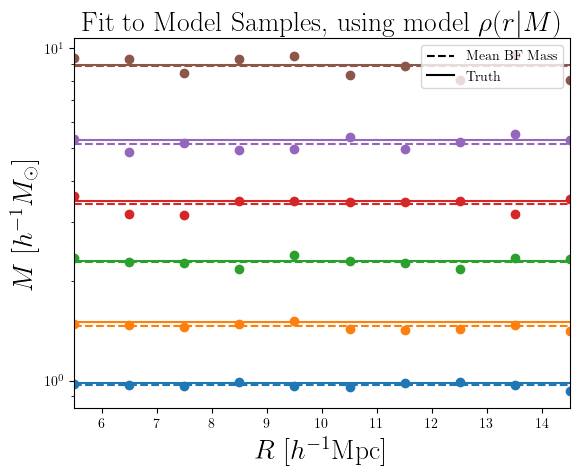

In [24]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots()

for k in range(len(mvirs)):#
    ax.scatter(r_cens, par_mass_ind[k, :, 0], c=f'C{str(k)}')
    ax.axhline(np.mean(par_mass_ind[k, :, 0]), ls='--', c=f'C{str(k)}')
    ax.axhline(mvirs[k], ls='-', c=f'C{str(k)}', )


marker_1 = Line2D(
    [0], [0],
    color='k',          
    marker='none',
    linestyle='--',
    label='Mean BF Mass', 

)

marker_2 = Line2D(
    [0], [0],
    color='k',          
    marker='none',
    linestyle='-',
    label='Truth'
)

ax.set_xlabel(r'$R\ [h^{-1}$Mpc]', fontsize=20)
ax.set_ylabel(r'$M \ [h^{-1} M_\odot]$', fontsize=20)
ax.set_yscale('log')
ax.margins(x=0)
ax.set_title(r'Fit to Model Samples, using model $\rho(r|M)$', fontsize=20)
plt.legend(handles=[marker_1, marker_2], fontsize=10, loc='upper right')

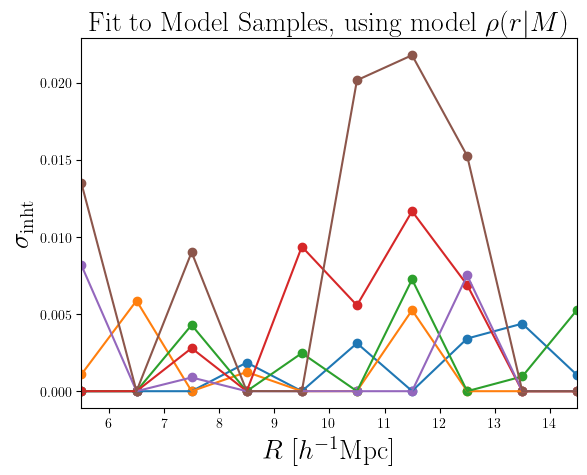

In [25]:
fig, ax = plt.subplots()

for k in range(len(mvirs)):#

    ax.scatter(r_cens, par_mass_ind[k, :, 1], c=f'C{str(k)}')
    ax.plot(r_cens, par_mass_ind[k, :, 1], c=f'C{str(k)}')

    #ax.axhline(np.mean(par_mass_ind[k, :, 1]), ls='--', c=f'C{str(k)}')
    #ax.axhline(mvirs[k], ls='-', c=f'C{str(k)}', )
    
ax.set_xlabel(r'$R\ [h^{-1}$Mpc]', fontsize=20)
ax.set_ylabel(r'$\sigma_{\rm inht}$', fontsize=20)
#ax.set_yscale('log')
ax.set_title(r'Fit to Model Samples, using model $\rho(r|M)$', fontsize=20)
ax.margins(x=0)

In [29]:
# MLE over masses simultaneously
par_mass_sim = np.zeros(6)
err_mass_sim = np.zeros(6)
p_init = mvirs #np.append(mvirs, 0.05)

Bounds = [(mbins[i]/1e14, mbins[i+1]/1e14) for i in range(len(mvirs))]

soln = scipy.optimize.minimize(lambda p: -RG_llh_sim(p, LOS_hists_dens), p_init, 
                            #bounds = Bounds, #[(0.5, 20.0), (0.5, 20.0), (0.5, 20.0), (0.5, 20.0), (0.5, 20.0), (0.5, 20.0)], #[(0.5, 20.0), (0, np.inf), (0, np.inf), (0, np.inf)], 
                            method='nelder-mead', 
                            options={'maxiter':10_000}
                            )

print("Initial: ",p_init) 
print("MLE: ", soln.x) 
print(soln.message)

par_mass_sim = soln.x 

Initial:  [0.98642004 1.4983     2.2963002  3.4653     5.3075     8.9311    ]
MLE:  [0.9722252 1.4698377 2.2707877 3.4128346 5.1813354 8.833643 ]
Optimization terminated successfully.


Text(0.5, 1.0, 'Fit to Model Samples, using model $\\rho(r|M)$')

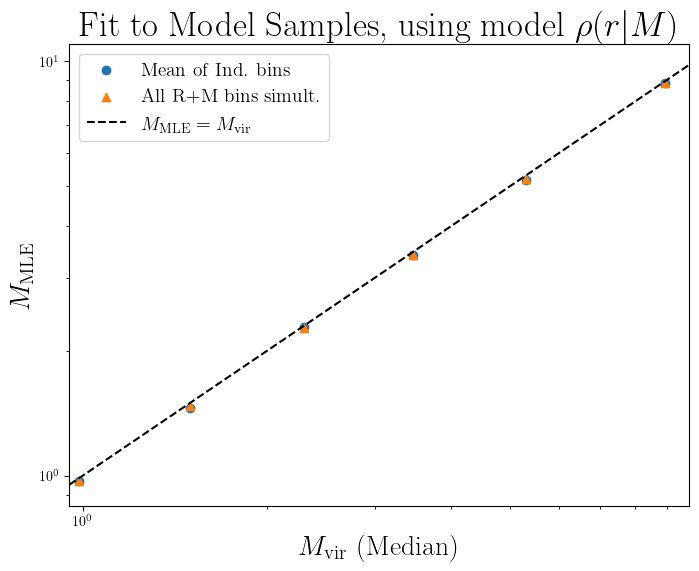

In [31]:
ms = np.linspace(0.95, 9.8, 100)

fig, ax = plt.subplots(figsize=(8,6))
#p, c = curve_fit(plawc, mvirs, par_mass[:, 0])
ax.scatter(mvirs, np.mean(par_mass_ind[:, :, 0], axis=-1), label='Mean of Ind. bins')
#ax.scatter(mvirs, par_mass[:, 0], marker='s', label=r'All R $|$ M')
ax.scatter(mvirs, par_mass_sim, marker='^', label='All R+M bins simult.')
ax.plot(ms, line(ms, 1, 0), c='k', ls='--', label=r'$M_{\rm MLE} = M_{\rm vir}$')
#ax.plot(ms, plawc(ms, p[0], p[1], p[2]), c='C3', ls='-', label=r'$a M_{\rm vir}^b+c$')
ax.margins(x=0)
ax.set_ylabel(r'$M_{\rm MLE}$', fontsize=20)
ax.set_xlabel(r'$M_{\rm vir}$ (Median)', fontsize=20)
ax.legend(fontsize=14)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim((0.95, 9.8))
ax.set_title(r'Fit to Model Samples, using model $\rho(r|M)$', fontsize=25)

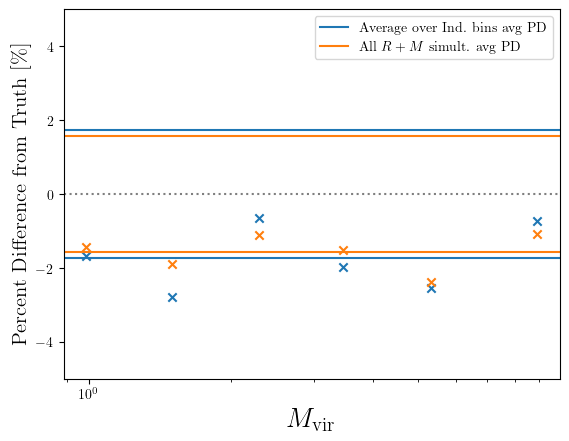

In [38]:
plt.scatter(mvirs, ((np.mean(par_mass_ind[:, :, 0], axis=-1)-mvirs)/mvirs)*100, marker='x')
plt.axhline(np.mean(np.abs((np.mean(par_mass_ind[:, :, 0], axis=-1)-mvirs)/mvirs))*100, label=r'Average over Ind. bins avg PD') 
plt.axhline(-np.mean(np.abs((np.mean(par_mass_ind[:, :, 0], axis=-1)-mvirs)/mvirs))*100 ) 


#plt.scatter(mvirs, ((par_mass_ind[:, 0]-mvirs)/mvirs)*100, marker='x')
#plt.axhline(np.mean(np.abs((par_mass_ind[:, 0]-mvirs)/mvirs))*100, label=r'All $R | M$', c='C1') 

plt.scatter(mvirs, ((par_mass_sim-mvirs)/mvirs)*100, marker='x')
plt.axhline(np.mean(np.abs((par_mass_sim-mvirs)/mvirs))*100, label=r'All $R+M$ simult. avg PD', c='C1') 
plt.axhline(-np.mean(np.abs((par_mass_sim-mvirs)/mvirs))*100, c='C1') 

plt.axhline(0.0, c='k', ls=':', alpha=0.5)
plt.xlabel(r"$M_{\rm vir}$", fontsize=20) 
plt.ylabel(r"Percent Difference from Truth $[\%]$", fontsize=15) 
plt.xscale('log')
plt.ylim((-5, 5))
plt.legend()

In [24]:
# compare integral with simulated densities to Pvlos histograms.

def P_vphys_R_simdens(vphys, R, M, pars=jocond.myconfig.joint_MAP, H=74.719, a=0.83760, h=0.6777):

    rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

    # rlos integration range
    rlos_max = 40 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(rlos_max + 1))
    rlos_cens = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    rlos_vals = rlos_cens

    vpec = vphys[:, None] - a * H * rlos_vals[None, :] / h

    vr_e = np.linspace(-4000, 4000, 100)
    vr_grid = 0.5 * (vr_e[1:] + vr_e[:-1])

    Pvlos_grid = np.array(
        [P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals]
    )

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        interp_func = interp1d(
            vr_grid, Pvlos_grid[j], kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vpec[:, j])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T

    #r3d = np.sqrt(R**2 + rlos_vals**2)
    k = np.where(M == Mvirs)[0][0]
    i = np.where(r_cens == R)[0][0]
    weight = N_R_rlos[k, i] / bin_vols[i] #rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)

    integrand = Pvlos_interp * weight[None, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, jocond.myconfig.cf_pars)
    P_out /= sigma_R

    return P_out / np.sum(P_out * np.diff(vphys)[0])

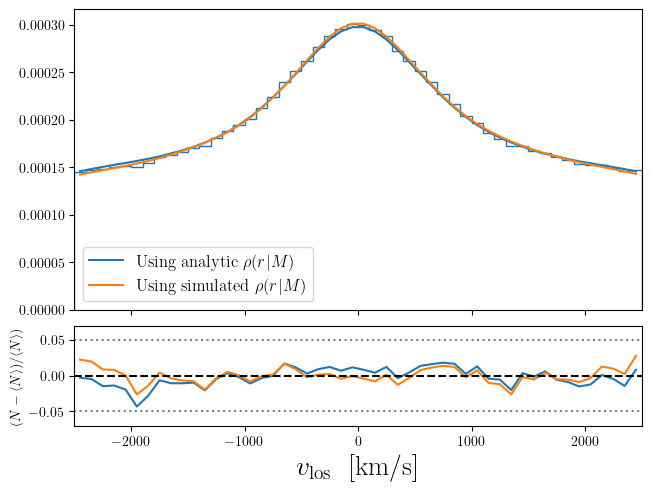

In [28]:
fig, ax = plt.subplots(2, 1, layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})

index = 5 + len(r_cens)*0
hist, vedges, _ = ax[0].hist(vphyslos_ls[index], range=[-2500, 2500], bins=50, histtype='step', density=True)
vcens = (vedges[1:]+vedges[:-1])/2.0

model_1 = P_vphys_R(vcens, r_cens[5], Mvirs[0], joint_MAP)
model_2 = P_vphys_R_simdens(vcens, r_cens[5], Mvirs[0], joint_MAP)

ax[0].plot(vcens, model_1, c='C0', label=r'Using analytic $\rho(r|M)$')
ax[0].plot(vcens, model_2, c='C1', label=r'Using simulated $\rho(r|M)$')
ax[0].legend(fontsize=12)

ax[1].plot(vcens, (hist - model_1)/model_1, c='C0')
ax[1].plot(vcens, (hist - model_2)/model_2, c='C1')
ax[1].axhline(0, c='k', ls='--')
ax[1].axhline(-0.05, c='k', ls=':', alpha=0.5) 
ax[1].axhline(0.05, c='k', ls=':', alpha=0.5) 
ax[1].set_xlabel(r'$v_{\rm los} \ $ [km/s]', fontsize=20)
ax[1].set_ylabel(r'$(N - \langle N \rangle)/\langle N \rangle)$', fontsize=10)
ax[1].set_ylim((-0.07, 0.07))

ax[0].margins(x=0)
ax[1].margins(x=0)


In [7]:
# try interpolating density profile

from scipy.interpolate import RegularGridInterpolator

rho_interp = RegularGridInterpolator((Mvirs, r_fine_cens), rho_RM, method='cubic', bounds_error=False, fill_value=None)


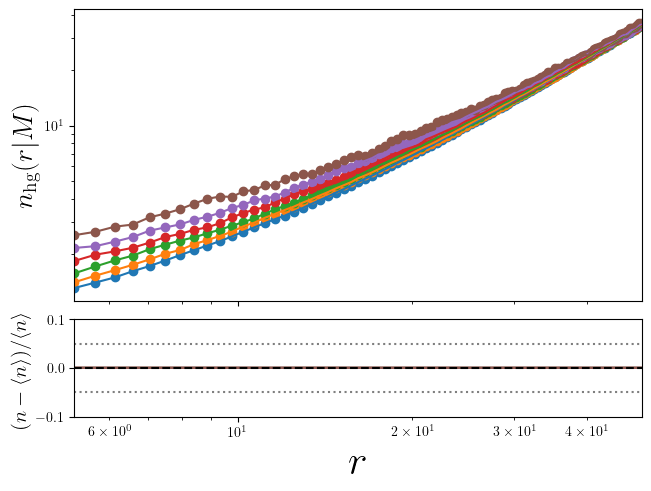

In [8]:
fig, ax = plt.subplots(2, 1, layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})

n_gal = 0.014

for k in range(len(Mvirs)):
    rho = ([rho_interp((Mvirs[k], ri)) for ri in r_fine_cens]) #n_gal*(1+cf_inf(r_fine_cens, Mvirs[k], cf_pars)) 
    ax[0].scatter(r_fine_cens, r_fine_cens**2*rho_RM[k], label=r'MDPL2')
    ax[0].plot(r_fine_cens, r_fine_cens**2*rho, label=r'MAP Model')

    ax[1].plot(r_fine_cens, (rho_RM[k] - rho)/rho)

ax[0].set_yscale('log')
ax[0].set_xscale('log')

ax[1].axhline(0, c='k', ls='--') 
ax[1].axhline(-0.05, c='k', ls=':', alpha=0.5) 
ax[1].axhline(0.05, c='k', ls=':', alpha=0.5) 

ax[1].set_xscale('log')
ax[1].set_ylim((-0.1, 0.1))

ax[0].set_ylabel(r'$n_{\rm hg}(r|M)$', fontsize=20)
ax[1].set_ylabel(r'$(n - \langle n \rangle )/\langle n \rangle$', fontsize=15)
ax[1].set_xlabel(r'$r$', fontsize=30)

ax[0].margins(x=0)
ax[1].margins(x=0)

In [9]:
# define model using interpolator

# compare integral with simulated densities to Pvlos histograms.

def P_vphys_R_simdens(vphys, R, M, pars=jocond.myconfig.joint_MAP, H=74.719, a=0.83760, h=0.6777):

    rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

    # rlos integration range
    rlos_max = 40 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(rlos_max + 1))
    rlos_cens = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    rlos_vals = rlos_cens

    vpec = vphys[:, None] - a * H * rlos_vals[None, :] / h

    vr_e = np.linspace(-4000, 4000, 100)
    vr_grid = 0.5 * (vr_e[1:] + vr_e[:-1])

    Pvlos_grid = np.array(
        [P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals]
    )

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        interp_func = interp1d(
            vr_grid, Pvlos_grid[j], kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vpec[:, j])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T

    r3d = np.sqrt(R**2 + rlos_vals**2)
    #k = np.where(M == Mvirs)[0][0]
    #i = np.where(r_cens == R)[0][0]
    weight = np.array([rho_interp((M, ri)) for ri in r3d]) #N_R_rlos[k, i] / bin_vols[i] #rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)

    integrand = Pvlos_interp * weight[None, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, jocond.myconfig.cf_pars)
    P_out /= sigma_R

    return P_out / np.sum(P_out * np.diff(vphys)[0]) 

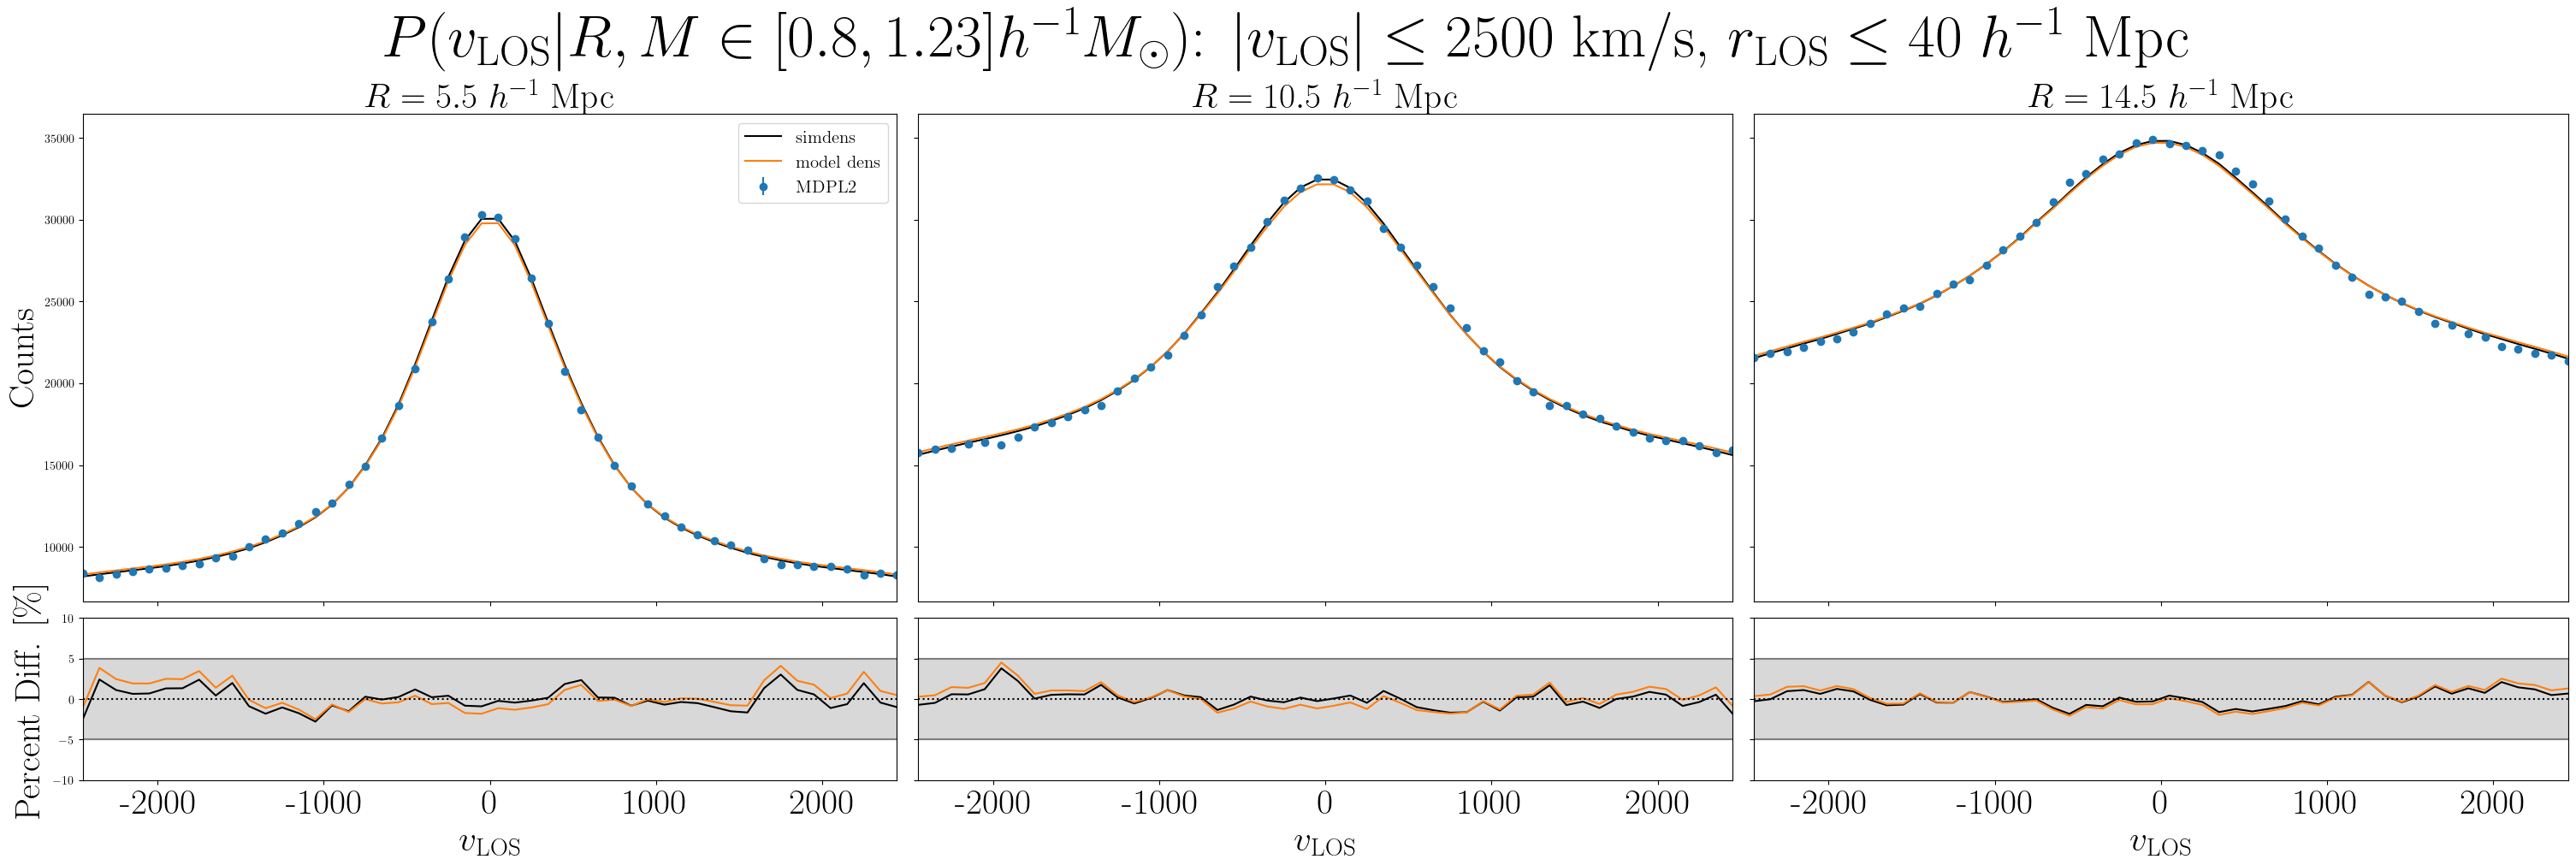

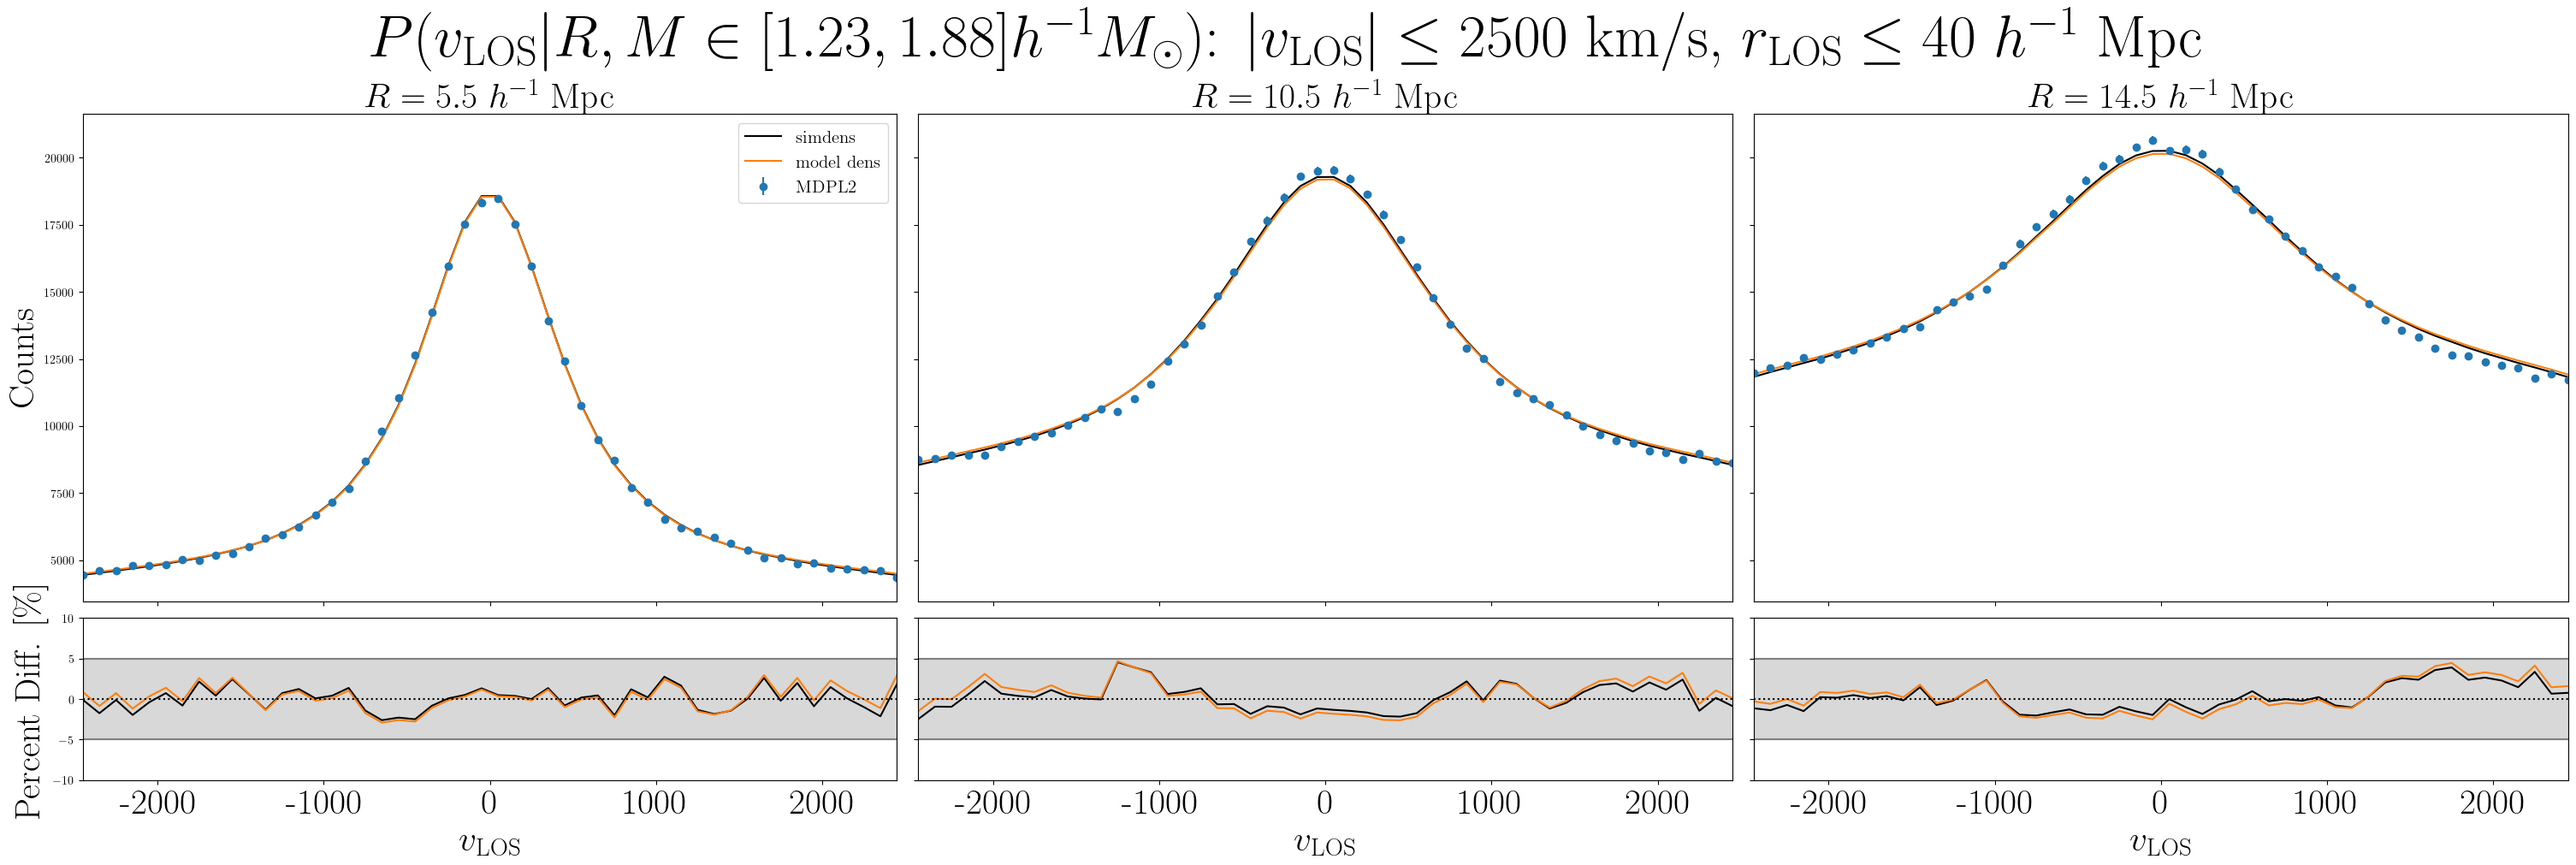

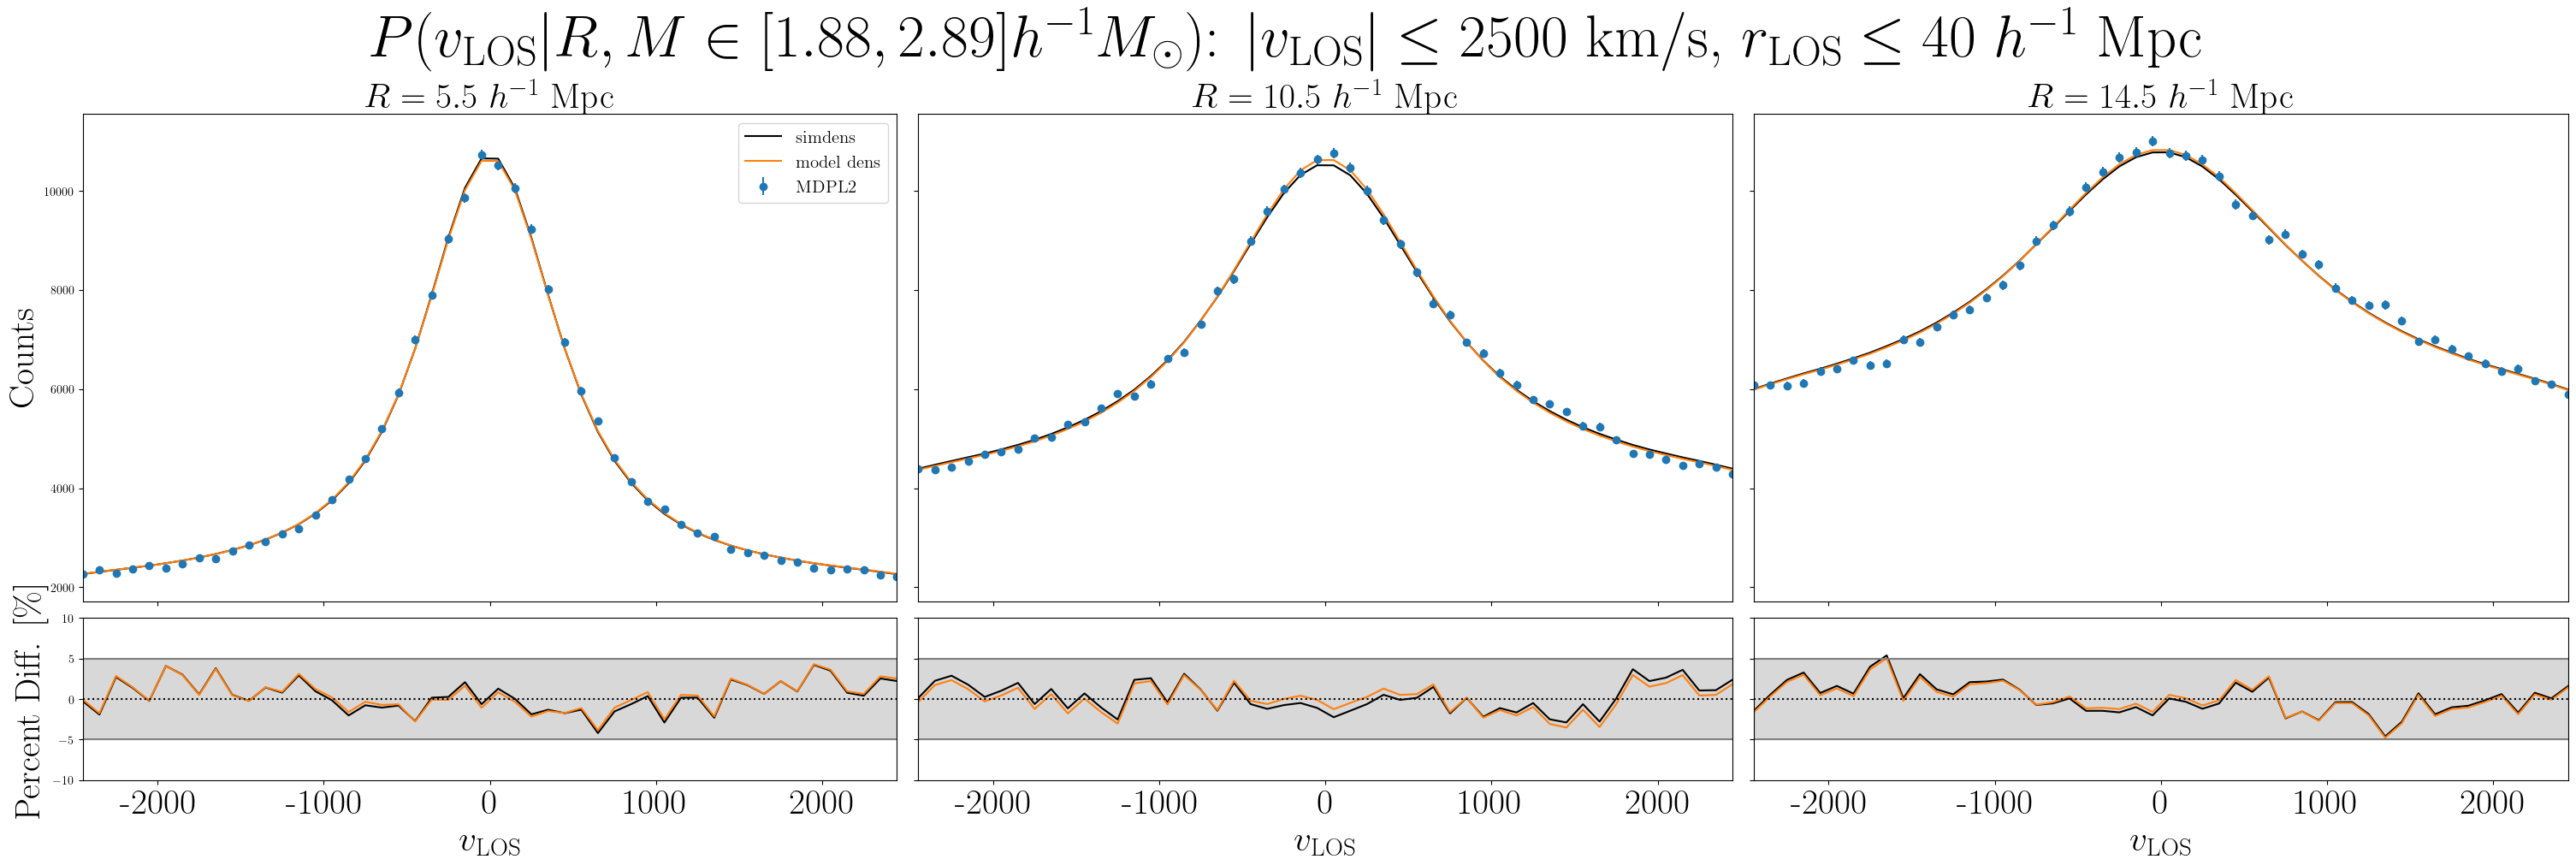

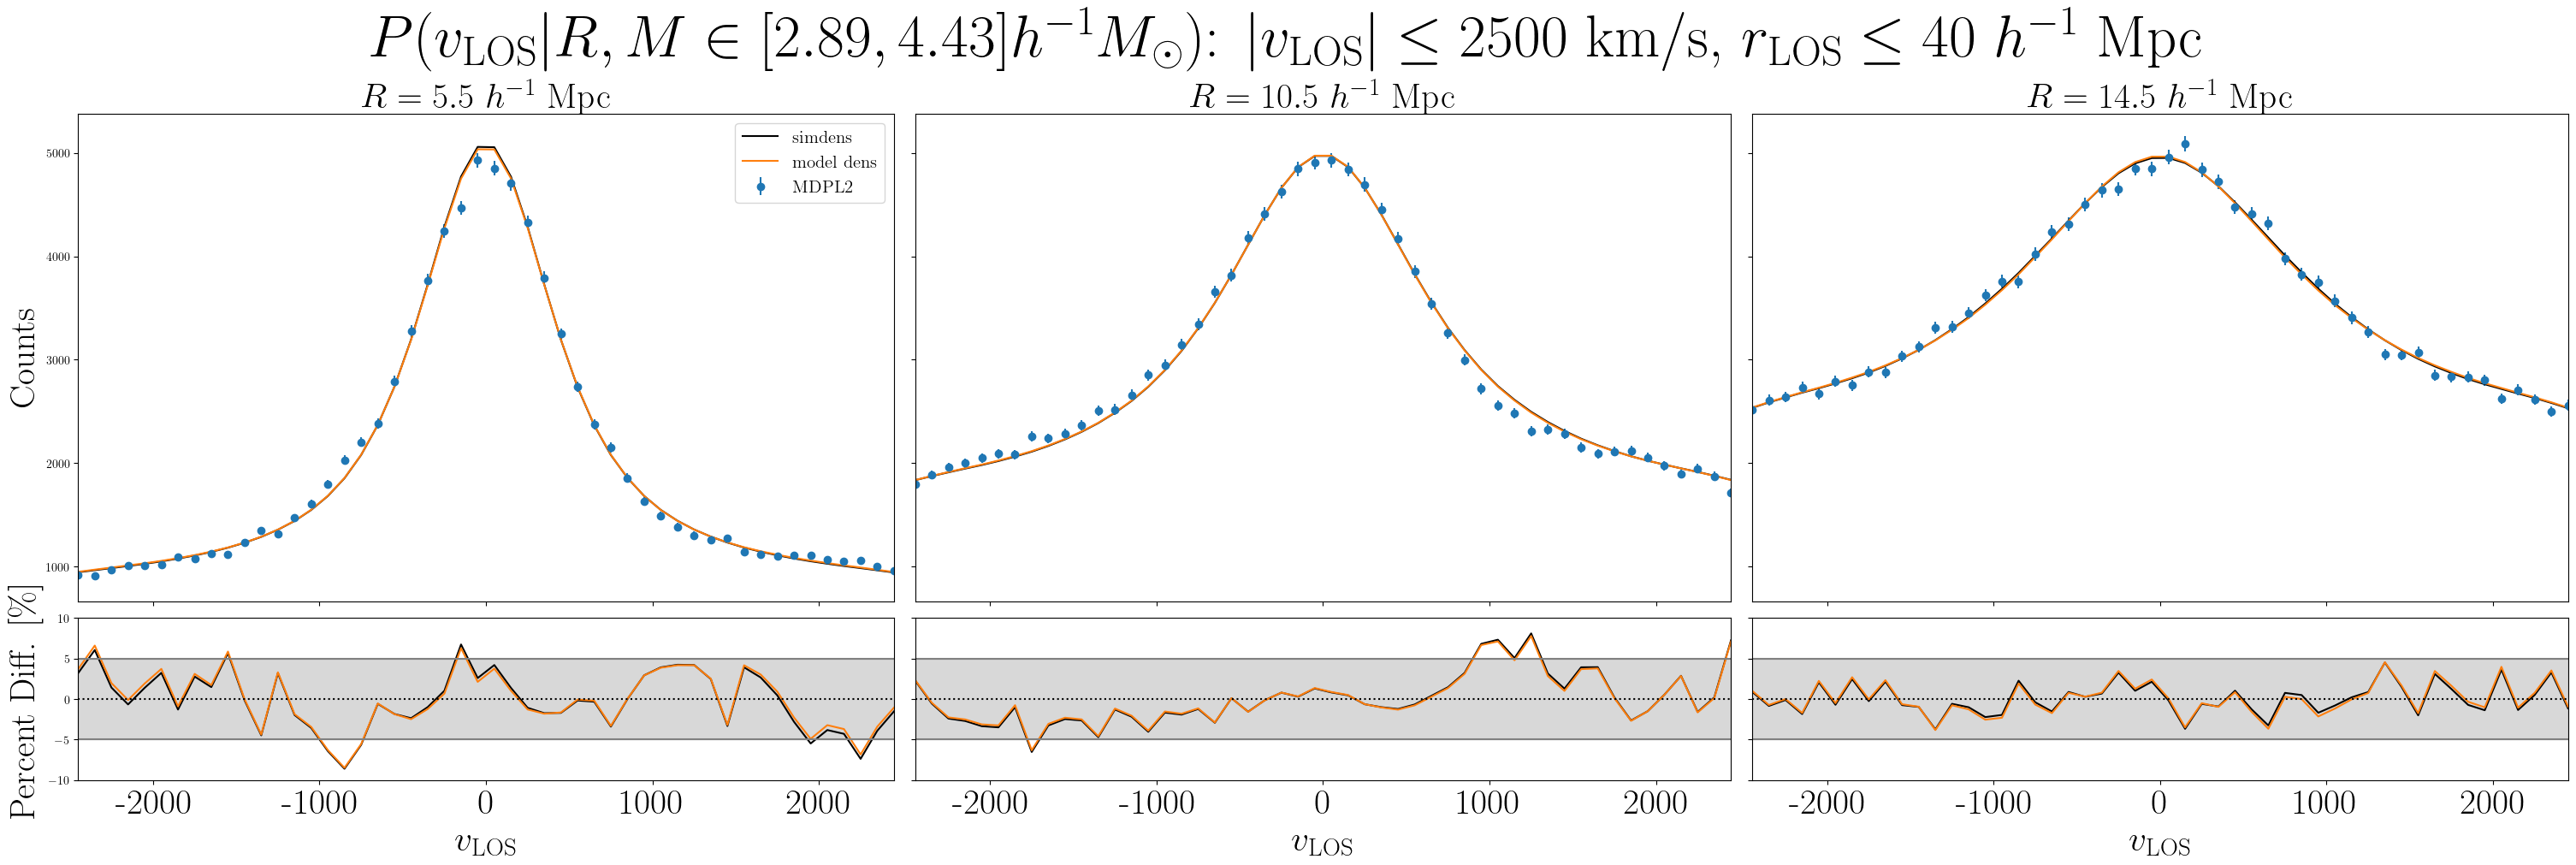

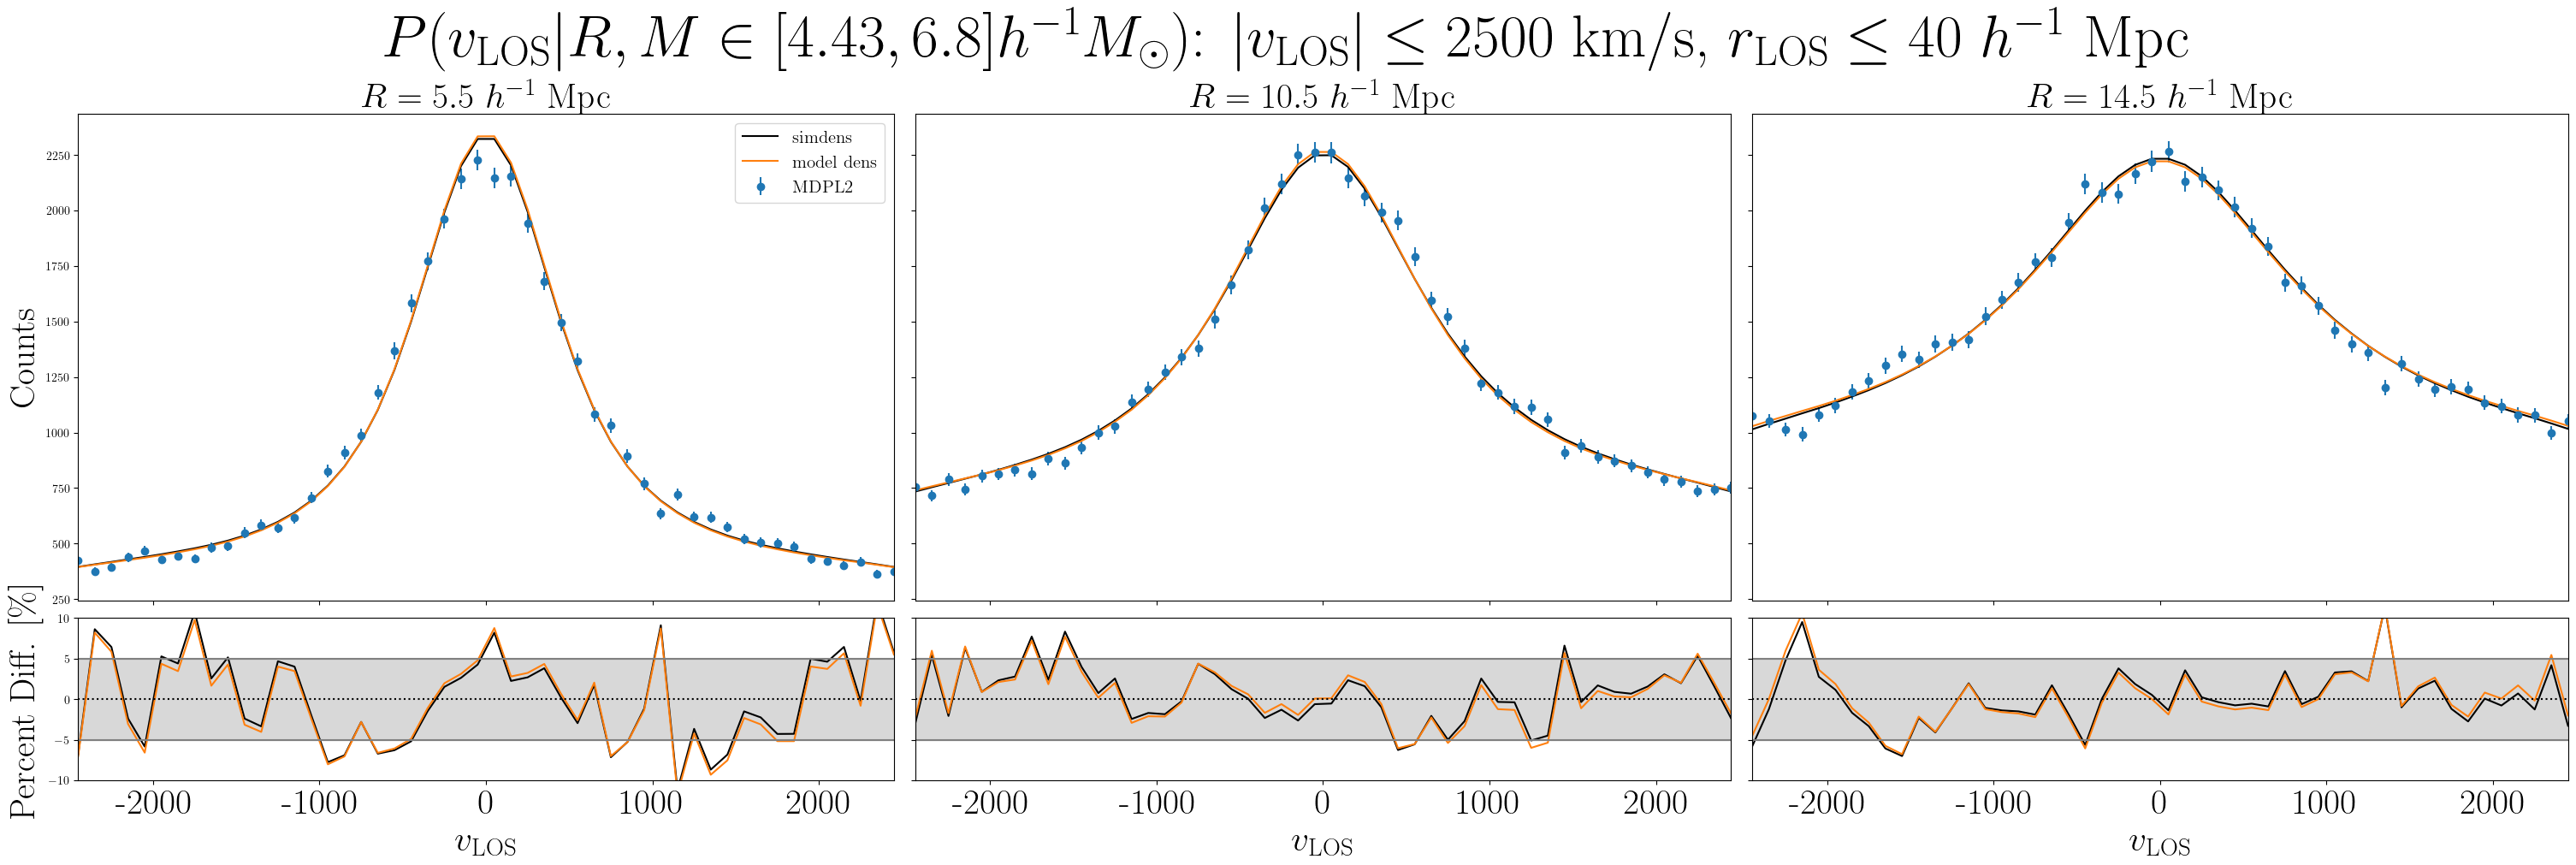

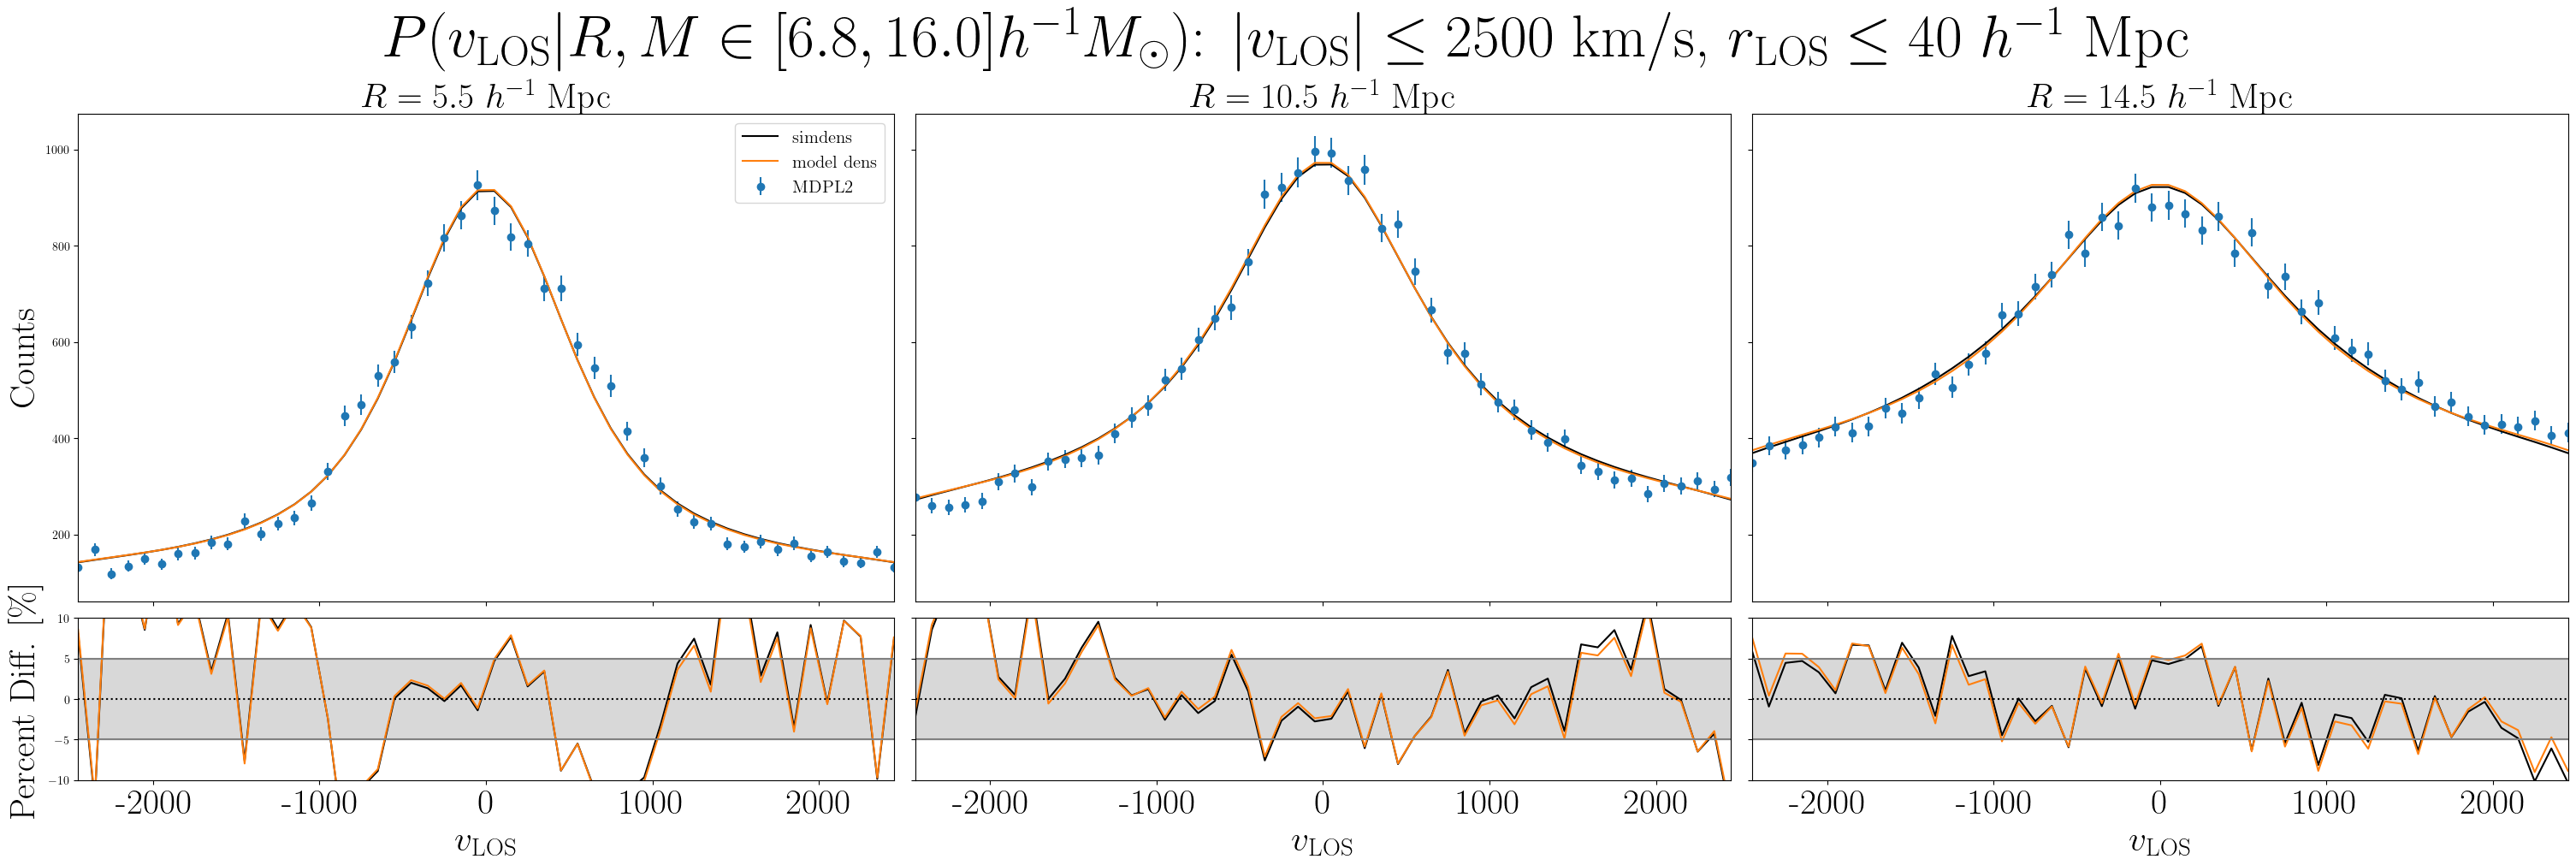

In [12]:
# validate

# check quality of "fit" over mass bins with vlos < 2K km/s 

# compare histograms  
mvirs = Mvirs/1e14
bin_num = 50 #120

r_select_inds = [0, 5, 9]
r_select = np.array([r_cens[i] for i in r_select_inds]) 

#for j in range(1):
for k in range(len(mvirs)):
    #k = 5
    fig, ax = plt.subplots(2, len(r_select), figsize=(30, 10), sharex=True, sharey='row', layout='constrained', gridspec_kw={'height_ratios': [3, 1]}) 
    for i, R in enumerate(r_select):

        index = r_select_inds[i] + k*len(r_cens)
        hist, bins_ex = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-2500, 2500], density=False)
        

        #hist_bin, bins_ex = np.histogram(vphyslos_bin[index], bins=bin_num, range=[-2500, 2500], density=False)
        

        #hist_ind, bins_ex = np.histogram(vphyslos_ind[index], bins=bin_num, range=[-2500, 2500], density=False)
        

        vcens = 0.5*(bins_ex[1:]+bins_ex[:-1])

        dist =  P_vphys_R_simdens(vcens, r_select[i], Mvirs[k]) #P_vphys_R_int(Mvals[inds[k]])[:, r_select_inds[i]]
        dist_out = P_vphys_R(vcens, r_select[i], Mvirs[k])


        N_avg = np.sum(hist)*dist*np.diff(vcens)[0]
        N_avg2 = np.sum(hist)*dist_out*np.diff(vcens)[0]
        #N_avg3 = np.sum(hist)*dist_out*np.diff(vcens)[0]

        ax[0, i].errorbar(vcens, hist, np.sqrt(hist), fmt='o', c=f'C0', label='MDPL2') #
        #ax[0, i].errorbar(vcens, hist_bin, np.sqrt(hist_bin), fmt='o', marker='s', c=f'C1', label='Model Samples') #
        #ax[0, i].errorbar(vcens, hist_ind, np.sqrt(hist_ind), fmt='o', marker='x', c=f'C{str(k)}') #

        ax[0, i].plot(vcens, N_avg, c='k', label='simdens')# 
        ax[0, i].plot(vcens, N_avg2, c='C1', label='model dens')# 
        #ax[0, i].plot(vcens, N_avg3, c='C0', label='BF to Sim')# 

        ax[0, i].set_title(r"$R={} \ h^{{-1}}$ Mpc".format(R), fontsize=30)
        ax[0, i].margins(x=0)

        ax[1, i].plot(vcens, (N_avg - hist)/hist * 100, c='k')
        ax[1, i].plot(vcens, (N_avg2 - hist)/hist * 100, c='C1')
        #ax[1, i].plot(vcens, (N_avg3 - hist)/hist * 100, ls=':', c='C0')

        #print(np.sum((N_avg - hist)**2/hist ), np.sum((N_avg3 - hist)**2/hist ))
        ax[1, i].axhline(0.0, c='k', ls=':')
        ax[1, i].axhline(5, c='gray', ls='-')
        ax[1, i].fill_between(vcens, 5, -5, color='gray', alpha=0.3)
        ax[1, i].axhline(-5, c='gray', ls='-')
        ax[1, i].set_ylim((-10, 10))
        ax[1, i].margins(x=0)
        ax[1, i].set_xlabel(r'$v_{\rm LOS}$', fontsize=30)
        ax[1, i].set_xticks([-2000, -1000, 0, 1000, 2000])
        ax[1, i].set_xticklabels(['-2000', '-1000', '0', '1000', '2000'], fontsize=30)
    ax[0, 0].legend(loc='upper right', fontsize=15)
    ax[0, 0].set_ylabel(r'Counts', fontsize=30)
    ax[1, 0].set_ylabel(r'Percent Diff. $[\%]$', fontsize=30)
    fig.suptitle(r"$P(v_{{\rm LOS}}|R, M\in[{}, {}] h^{{-1}}M_\odot)$: $|v_{{\rm LOS}}| \leq {}$ km/s, $r_{{\rm LOS}} \leq 40 \ h^{{-1}}$ Mpc".format(round(mbins[k]/1e14, 2), round(mbins[k+1]/1e14, 2), 2500), fontsize=50)  